# Predicting Cancellations in Hotel Reservations (Phase 2)

Author: Jialun Darren Huang

## Table of Contents
1. [Setting up Imports, Helpers, and Globals](#setup)
2. [Load the Dataset](#load-dataset)
3. [Introduction](#introduction)<br>
    3.1. [Phase 1 Summary](#phase-one-summary)<br>
    3.2. [Report Overview](#report-overview)<br>
    3.3. [Overview of Methodology](#overview-of-methodology)<br>
4. [Predictive Modelling](#predictive-modelling)<br>
    4.1. [Preprocessing Dataset](#pp-dataset)<br>
    4.2. [Feature Selection](#feature-selection)<br>
    4.3. [Model Fitting & Tuning](#model-fitting-tuning)<br>
    4.4. [Neural Network Model Fitting & Tuning](#neural-network-model-fitting-tuning)<br>
    4.5. [Model Comparison](#model-comparison)
5. [Critique & Limitations](#critique-limitations)
6. [Summary & Conclusions](#summary-conclusions)<br>
    6.1. [Project Summary](#project-summary)<br>
    6.2. [Summary of Findings](#summary-of-findings)<br>
    6.3. [Conclusions](#conclusions)<br>
    6.4. [Next Steps](#next-steps)<br>
7. [References](#references)

---

## <a id = "setup">1. Setting up Imports, Helpers, and Globals<a/>

### Import Python Libraries

We load the modules that we will use throughout the report.

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import probplot, skew, shapiro, ttest_rel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, MinMaxScaler
from sklearn.feature_selection import f_classif, SelectKBest

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, make_scorer

from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.optimizers import SGD, schedules
from scikeras.wrappers import KerasClassifier

import tensorflow as tf
import random
import os

### Run Helper Functions and Global Variables

In this project, we will be separating helper functions and global variables from the main code for better readability and code management. 

In [2]:
# Ignore warnings
warnings.filterwarnings("ignore")

# Display all columns for dataframes
pd.set_option('display.max_columns', None)

# Setting visualisation style
plt.style.use("seaborn-v0_8")

# Fix random_state for the whole project
random_state = 42

# Fix verbose for the whole project
verbose_category = 1

In [3]:
# Display data distribution
def DisplayDistribution(df, col):
    fig, (ax_hist, ax_qq) = plt.subplots(1, 2, figsize = (12, 5))
    fig.suptitle(f"Distribution for {col}")
    
    data = df[col].sample(n = 5000, random_state = random_state)

    # Histogram
    sns.histplot(data, ax = ax_hist)
    ax_hist.set_title("Histogram")

    # Q-Q Plot
    probplot(data, dist = "norm", plot = ax_qq)
    ax_qq.set_title("Q-Q Plot")

    plt.show()

    _, p_val = shapiro(data)

    print(f"Statistics for the numerical column: {col}")
    print(f"Skewness: {skew(data)}")
    print(f"Shapiro-Wilk test p-value: {p_val}")
    
    if p_val > 0.05:
        print("p-value is more than 0.05, We fail to reject noramlity in distribution")
    else:
        print("p-value is equal or less than 0.05, We reject noramlity in distribution")
    print()

In [4]:
# For One-Hot Encoding
def Ohe_Features(df, ohe, features, transform_only = False):
    if transform_only:
        enc = ohe.transform(df[features])
    else:
        enc = ohe.fit_transform(df[features])
        
    enc_df = pd.DataFrame(enc, columns = ohe.get_feature_names_out(features), index = df.index).astype(np.int64)

    df = df.join(enc_df)
    df = df.drop(features, axis = 1)
    
    return df

In [5]:
# For Power Transformation
def PowerTransform_Features(df, pt, features, transform_only = False):
    if transform_only:
        scaled = pt.transform(df[features])
    else:
        scaled = pt.fit_transform(df[features])
        
    scaled_df = pd.DataFrame(scaled, columns = pt.feature_names_in_, index = df.index)

    # Unlike OHE, since the feature names are the same, we drop the original values first before joining it with the new values
    df = df.drop(features, axis = 1)
    df = df.join(scaled_df)    
    
    return df

In [6]:
# Displaying the best score and parameters after running GridSearchCV
def DisplayBestParameterResults(model):
    print(f"Best Score: {model.best_score_}")
    print(f"Best Params: {model.best_params_}")

In [7]:
# Displays plots for tuning hyperparameters (For Logistic Regression, Decision Tree and Random Forest)
def Display_HP_Tuning_Univariate(cv_results_df, hyperparam, ax):    
    cv_results_df = cv_results_df.loc[:, [hyperparam, "mean_test_score"]].sort_values(by = [hyperparam, "mean_test_score"]).reset_index()
    cv_results_df["index_val"] = cv_results_df.groupby(hyperparam).cumcount()
    
    sns.lineplot(data = cv_results_df, x = "index_val", y = "mean_test_score", hue = hyperparam, ax = ax)

In [8]:
# Used for Neural Network random seed/random state
def set_seed():
    os.environ["PYTHONHASHSEED"] = str(random_state)    
    np.random.seed(random_state)
    random.seed(random_state)
    tf.random.set_seed(random_state)

In [9]:
# Creates the model_factor for Neural Networks
def model_factory(input_dim, learning_rate, 
                  layer1_units, layer2_units, 
                  layer1_dropout_rate, layer2_dropout_rate, 
                  layer1_activation, layer2_activation,
                  loss = "binary_crossentropy"):
    
    model = Sequential()
    model.add(Input(shape = (input_dim, )))
    
    model.add(Dense(layer1_units, activation = layer1_activation))
    model.add(Dropout(layer1_dropout_rate))
    
    model.add(Dense(layer2_units, activation = layer2_activation))
    model.add(Dropout(layer2_dropout_rate))
    
    model.add(Dense(1, activation = "sigmoid"))

    model.compile(loss = loss, optimizer = SGD(learning_rate = learning_rate), metrics = ["accuracy"])
    
    return model

In [10]:
# Displays plots for tuning hyperparameters (For Neural Network)
def Display_NN_HP_Tuning(history_list, hyperparam_name, hyperparam_values):
    # Creating the history dataframe for all 
    hist_lr_df = pd.DataFrame(columns = [hyperparam_name, "accuracy", "loss", "val_accuracy", "val_loss"])

    for lr_val, hist in zip(hyperparam_values, history_list):
        new_df = pd.DataFrame(hist.history)
        hist_lr_df = pd.concat([hist_lr_df, new_df])
        hist_lr_df.loc[hist_lr_df[hyperparam_name].isna(), hyperparam_name] = lr_val
    
    hist_lr_df["index_val"] = hist_lr_df.groupby(hyperparam_name).cumcount()

    # Setting palette colours
    palette = sns.color_palette("Set2", len(hyperparam_values))
    palette_dict = dict(zip(hyperparam_values, palette))

    # Draw graphs
    fig, axList = plt.subplots(2, 2, figsize = (12, 12))
    axList = axList.ravel()
    
    fig.suptitle(f"Hyperparameter Tuning with Neural Network - {hyperparam_name}")
    
    for i, (ax, metric_scoring) in enumerate(zip(axList, ["accuracy", "loss", "val_accuracy", "val_loss"])):
        sns.lineplot(data = hist_lr_df, x = "index_val", y = metric_scoring, hue = hyperparam_name,
                     palette = palette_dict, ax = ax)
    
        ax.set_xlabel("Epochs")
    
        if i == 0:
            handles, labels = axList[0].get_legend_handles_labels()
    
        ax.legend().remove()
    
    fig.legend(handles, labels, title = hyperparam_name, loc = "center left", bbox_to_anchor = (1.02, 0.5))
        
    plt.tight_layout()
    plt.show()

In [11]:
# Display the history, for Neural Networks
def plot_history(history):
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    
    plt.title("Model Accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    
    plt.legend(["Train", "Validation"], loc = "lower right")
    
    plt.show()

---

## <a id = "load-dataset">2. Load the Dataset<a/>

In [12]:
df = pd.read_csv("hotel_reservations_data.csv")

In [13]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [14]:
df.dtypes

Booking_ID                               object
no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
room_type_reserved                       object
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
market_segment_type                      object
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object

---

## <a id = "introduction">3. Introduction<a/>

### <a id = "phase-one-summary">3.1. Phase 1 Summary<a/>

In Phase 1, we look into the hotel booking cancellation dataset by analysing the features, performed data cleaning and preparation, and exploratory data analysis tasks. 

To begin, we examined the dataset structure, where we understand what the different features represent, and how they relate to hotel cancellations. We also classify them under independent features and the dependent or target feature.

We also conducted data cleaning and preparation to address common issues found in the datasets, such as working with inconsistent cardinality, missing values and incorrect data types. This cruical step helps improve the data quality and integrity before conducting further analysis.

In exploratory data analysis, we analyse patterns, correlations between features. We use graphical visualisation tools to support our findings and any potential features or patterns that may influence cancellations in hotel bookings.

Continuing from Phase 1, we will be building predictive machine learning models in Phase 2. These models are aimed to identify and predict hotel booking cancellations. The outcomes from Phase 1 provided us a dataset with high data integrity and quality, as well as offering insightful patterns that can guide model and algorithm selections.

### <a id = "report-overview">3.2. Report Overview<a/>

This report shows a complete predictive modelling methodology and workflow. We have split the report into key steps.

Data preprocessing, where we encode categorical variables and scaling numerical features. Feature Selection where we show how we select relevant or features with strong preditive power.

We also show the model training and tuning process for 4 different models - Logistic Regression, Decision Tree, Random Forest and Neural Networks. These models also have their hyperparameters tuned for optimal performance, and then are evaluated to determine the best performing model from each algorithm, as well as being the overall best performing model.

We finally conclude our findings with a summary and conclusion, and discuss issues and limitations, and ways we can improve in the project.

### <a id = "overview-of-methodology">3.3. Overview of Methodology<a/>

In Phase 2, the goal is to create predictive machine learning models that can predict whether a guest would be cancelling their hotel booking based on the booking patterns.

First, the dataset has to be preprocessed, specifically encoding categorical variables and applying feature scaling to numerical variables. This ensures that the features are compatible with the machine learning algorithms, and no one feature has too much influence or outweights the others, as this can negatively impact the model training process and performance.

Next, we will conduct feature selection. We identify features with strong predictive powers, and drop features that are not useful. By reducing the dimensionality of the dataset, this helps reduce the computational time needed and lowers the model complexity required to train the models. We will use visualisation graphs to further understand the features that are are good and bad for modelling.

Before training the models, we will need to split the dataset into training and testing datasets. The training datasets would be solely used to train the models, while the testing dataset will act as the final benchmark, to evaluate how well the models is able to generalise and predict with unseen data

For model training, we will train the models one at a time, starting with Logistic Regression, followed by Decision Trees, Random Forest and Neural Networks. In each model training process, we will be looking at a couple of hyperparameters that we can fine tune and the outcomes of the tuning process with graphical visualisations.

Finally, we compare the models with appropriate evaluation metrics, and provide an assessment of the model effectiveness to predict hotel booking cancellations with the unseen test dataset that we reserved earlier.

---

## <a id = "predictive-modelling">4. Predictive Modelling<a/>

In this section, we will be going through the step-by-step process for building predictive models.

### <a id = "pp-dataset">4.1. Preprocessing Dataset<a/>

Lets start by preprocessing the dataset for modelling.

#### Quick check for missing values

In [15]:
df.isna().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

There are no missing values.

#### Dropping Features

Before we conduct feature selection, lets remove features that are not useful for modelling.

As the unique value for the dataset, `Booking_ID` does not offer any information to the booking outcome, nor does it help much during Data Analysis. It should therefore, be removed.

In [16]:
df = df.drop("Booking_ID", axis = 1)

We are also going to drop all arrival date-related features `arrival_year`, `arrival_month` and `arrival_date`. Although these may potentially have useful information, such as bookings pattern varying by month due to holiday and seasonal trends, the arrival dates in the dataset are widely spread out, making it difficult to extract meaningful information. These features are unlikely to contribute significantly to the model's predictive power.

If necessary, you can try building a time-series model as an alternative to analyse and predict booking cancellations

In [17]:
df = df.drop(["arrival_year", "arrival_month", "arrival_date"], axis = 1)

In [18]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,Online,0,0,0,94.50,0,Canceled


In [19]:
df.shape

(36275, 15)

There are 36275 observations and 15 features

#### Splitting Dataset

Another important step before modelling is to split the dataset into training and testing set.

The training set is solely used to train the data, where the model can learn and generalise patterns and relationships of the descriptive features to the target feature.

The testing set acts as unseen or new data, that we can use to test the model's performance. No information in the testing data should be used to build the machine learning model, as doing so may lead to data leakage. This would cause poor results from biased estimations and overfitting, where the model is trained on and performs well on leaked data, but fails to generalise to completely new and unseen data.

In this project, we will be splitting the dataset 80:20 ratio. 80% of the dataset (29020 observations) would be used to train the model, and the rest of the dataset (7255 observations) would be reserved for testing and performance evaluation.

In [20]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'market_segment_type',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status'],
      dtype='object')

In [21]:
numerical_features = ["no_of_adults", "no_of_children", "no_of_weekend_nights", "no_of_week_nights", 
                      "lead_time", "no_of_previous_cancellations", "no_of_previous_bookings_not_canceled", 
                      "avg_price_per_room", "no_of_special_requests"]

binary_cateogrical_features = ["required_car_parking_space", "repeated_guest"]

multi_categorical_features = ["type_of_meal_plan", "room_type_reserved", "market_segment_type"]

target_feature = ["booking_status"]

In [22]:
df["booking_status"].value_counts(normalize = True)

booking_status
Not_Canceled    0.672364
Canceled        0.327636
Name: proportion, dtype: float64

Before splitting, we must take note of two important considerations

1) Splitting by stratifying target feature
The target feature `booking_status` has a binary classifcation distribution as follows:

- Not_Canceled -> 67.24%
- Canceled -> 32.76%

While this distribution is not very imbalanced, it is still important to have the same class proportions in both training and testing dataset, as a poor split leading to a class imbalance, may result in bias model training, resulting to poor generalisation and evaluation scores.

To ensure the class distribution is similar in both training and testing datasets, we will use the `stratify=` parameter in `train_test_split`.

2) Preserving the different/unique values for One Hot Encoding features

Another concern is ensuring that all unique categorical values intended for One Hot Encoding are seen in the training dataset.

To give an example, lets say we have an original dataset with the categorical feature "Emotion", with the values "Happy", "Neutral" and "Sad".

If the training dataset ended up with only "Happy" and "Neutral" after `train_test_split`, and we conduct One Hot Encoding, the One Hot Encoder would not be aware of "Sad". This may result in missing encoded features, incorrect feature dimensions (should be two dummy features instead of one to represent all three encoded values)

Therefore, we have to ensure that all categorical values that will be One Hot Encoded are seen in the training dataset. To do so, we will inspect these features after splitting, and check that all the unique values are found in both training and to the original dataset.

##### Split the Dataset

In [23]:
x_data = df.drop(target_feature, axis = 1)
y_data = df[target_feature]

In [24]:
# Convert this to numpy array binary representation before splitting
y_data = np.array(y_data[target_feature].replace({"Not_Canceled": 0, "Canceled": 1})).ravel()
y_data

array([0, 0, 1, ..., 0, 1, 0], dtype=int64)

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size = 0.2, random_state = random_state)

##### Verify Split (by Dataset Dimensions)

In [26]:
print(f"Dim of x_train: {x_train.shape}")
print(f"Dim of x_test: {x_test.shape}")
print(f"Dim of y_train: {y_train.shape}")
print(f"Dim of y_test: {y_test.shape}")

Dim of x_train: (29020, 14)
Dim of x_test: (7255, 14)
Dim of y_train: (29020,)
Dim of y_test: (7255,)


The dimensions are right.

##### Verify Split (by Class Imbalance)

In [27]:
df[target_feature].value_counts(normalize = True)

booking_status
Not_Canceled      0.672364
Canceled          0.327636
Name: proportion, dtype: float64

In [28]:
print(f"Proportion of Training Dataset: {sum(y_train == 0)/len(y_train)}")
print(f"Proportion of Testing Dataset: {sum(y_train == 1)/len(y_train)}")

Proportion of Training Dataset: 0.6737077877325982
Proportion of Testing Dataset: 0.3262922122674018


In [29]:
print(f"Proportion of Training Dataset: {sum(y_test == 0)/len(y_test)}")
print(f"Proportion of Testing Dataset: {sum(y_test == 1)/len(y_test)}")

Proportion of Training Dataset: 0.6669882839421089
Proportion of Testing Dataset: 0.3330117160578911


For the target feature `booking_status`, we can see that both train and testing datasets have closely similar proportions classes.

##### Verify Split (by Unique Values for One Hot Encoding features)

In [30]:
for col in multi_categorical_features:
    print(f"For the column: {col}")
    print("Original dataset")
    print(sorted(df[col].unique()))
    print("Training dataset")
    print(sorted(x_train[col].unique()))
    print()

For the column: type_of_meal_plan
Original dataset
['Meal Plan 1', 'Meal Plan 2', 'Meal Plan 3', 'Not Selected']
Training dataset
['Meal Plan 1', 'Meal Plan 2', 'Meal Plan 3', 'Not Selected']

For the column: room_type_reserved
Original dataset
['Room_Type 1', 'Room_Type 2', 'Room_Type 3', 'Room_Type 4', 'Room_Type 5', 'Room_Type 6', 'Room_Type 7']
Training dataset
['Room_Type 1', 'Room_Type 2', 'Room_Type 3', 'Room_Type 4', 'Room_Type 5', 'Room_Type 6', 'Room_Type 7']

For the column: market_segment_type
Original dataset
['Aviation', 'Complementary', 'Corporate', 'Offline', 'Online']
Training dataset
['Aviation', 'Complementary', 'Corporate', 'Offline', 'Online']



While expected with 29020 observations, we can confirm that the features undergoing one hot encoding in training dataset contains all unique values similar to the original dataset

In [31]:
for col in binary_cateogrical_features:
    print(f"For the column: {col}")
    print("Original dataset")
    print(sorted(df[col].unique()))
    print("Training dataset")
    print(sorted(x_train[col].unique()))
    print()

For the column: required_car_parking_space
Original dataset
[0, 1]
Training dataset
[0, 1]

For the column: repeated_guest
Original dataset
[0, 1]
Training dataset
[0, 1]



Just to have a look for binary categorical features. Do note, for binary categorical features, we can still use One Hot Encoding, but set `drop="first"`, to remove unnecessary dummy variables. That said, since they are already binary integer values (0 and 1), we are good to go!

#### One Hot Encoding Categorical Features

One hot encoding is a technique used to convert categorical variables into a numerical values.

It creates new binary integer columns for each unique value in the categorical feature, and assigns 1 to the unique value present in each observation, and 0s to the rest. This helps the model understand the categorical features through numerical values, that machine learning models can use and understand.

In [32]:
m_ohe = OneHotEncoder(handle_unknown = "ignore", sparse_output = False)

In [33]:
x_train_pp = Ohe_Features(x_train, m_ohe, multi_categorical_features)

In [34]:
x_train[multi_categorical_features].sample(n = 5, random_state = random_state)

,type_of_meal_plan,room_type_reserved,market_segment_type
15198,Meal Plan 1,Room_Type 1,Offline
10571,Meal Plan 1,Room_Type 4,Online
22722,Meal Plan 1,Room_Type 1,Offline
746,Meal Plan 2,Room_Type 1,Offline
11548,Meal Plan 1,Room_Type 4,Online


In [35]:
x_train_pp[m_ohe.get_feature_names_out(multi_categorical_features)].sample(n = 5, random_state = random_state)

,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 1,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
15198,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
10571,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
22722,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
746,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0
11548,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


We can see that One Hot Encoding has changed multi-categorical features to one hot encoded features well.

In [36]:
print(x_train[binary_cateogrical_features].dtypes)

for col in x_train[binary_cateogrical_features]:
    print(f"Unique values in {col}: {x_train[col].unique()}")

required_car_parking_space    int64
repeated_guest                int64
dtype: object
Unique values in required_car_parking_space: [0 1]
Unique values in repeated_guest: [0 1]


Since the binary categorical features are already 0s and 1s, we do not need to perform any additional steps.

#### Scaling or Transforming Numeric Features

For numerical features, we will be applying scaling or transforming techniques, to change the numerical values to a similar numerical scales.

A dataset with numerical features containing different ranges and density, such as having very small and large values, may result in the machine learning model putting more weight to features with larger values, and less to features with smaller values.

By scaling the features, with standardisation/normalisation or transformation, we can ensure that all features are seen more fairly and equally, helping the model to generalise better.

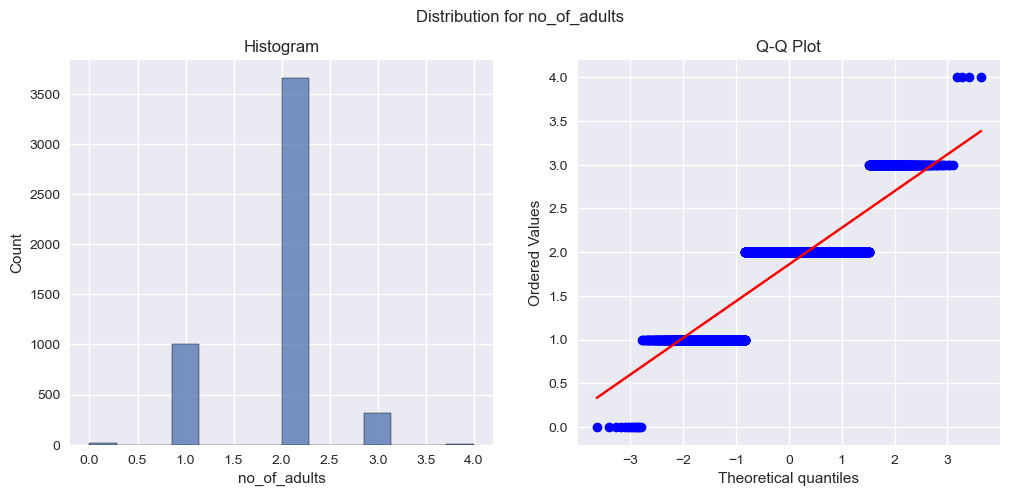

Statistics for the numerical column: no_of_adults
Skewness: -0.3051992559390603
Shapiro-Wilk test p-value: 1.0235033977241262e-70
p-value is equal or less than 0.05, We reject noramlity in distribution



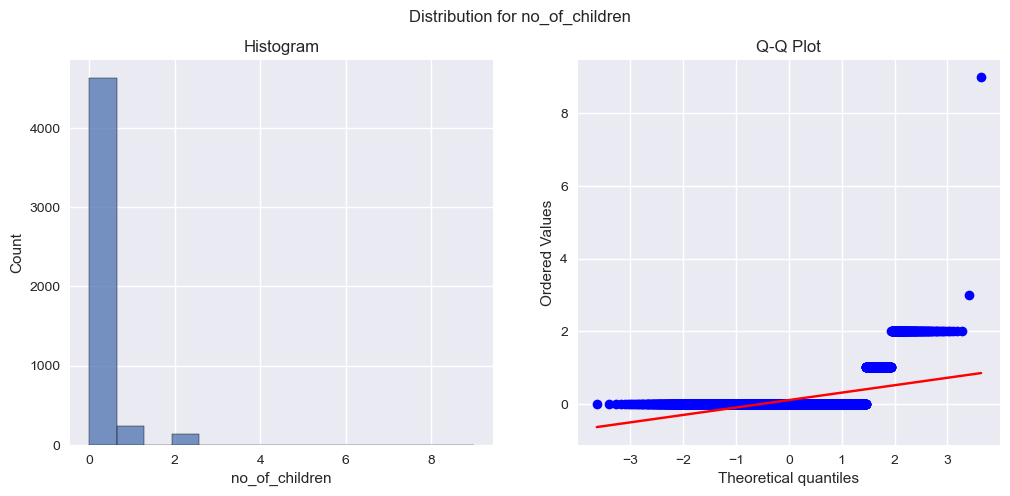

Statistics for the numerical column: no_of_children
Skewness: 5.687078335965464
Shapiro-Wilk test p-value: 1.2006395494003734e-88
p-value is equal or less than 0.05, We reject noramlity in distribution



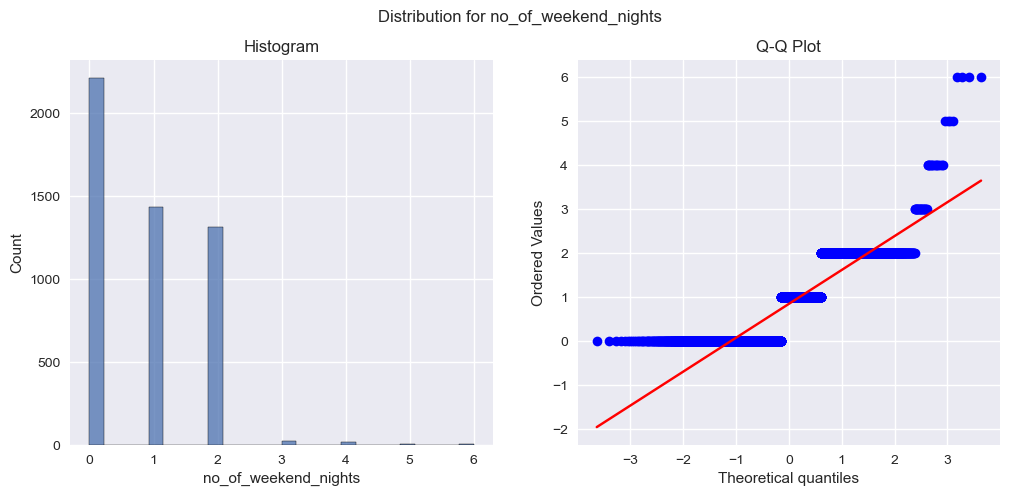

Statistics for the numerical column: no_of_weekend_nights
Skewness: 0.6667893394213372
Shapiro-Wilk test p-value: 6.444044697687882e-63
p-value is equal or less than 0.05, We reject noramlity in distribution



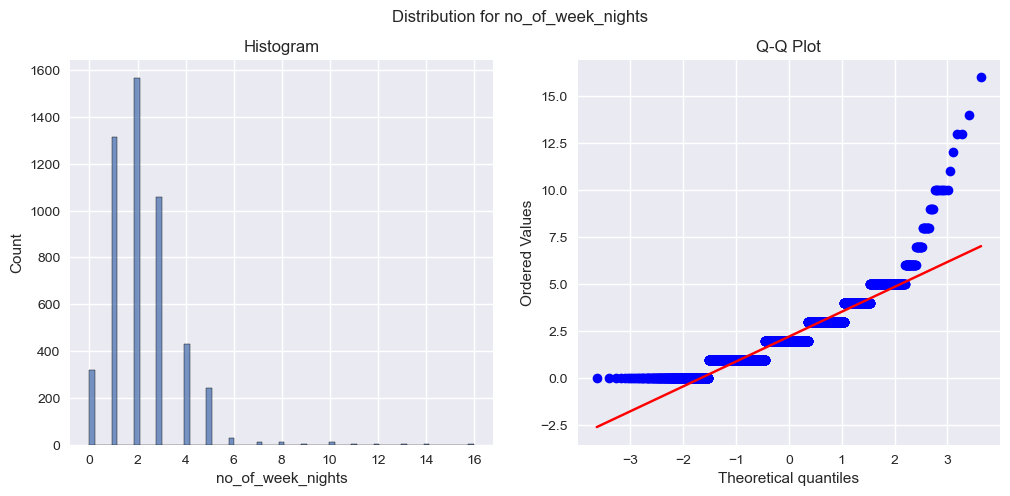

Statistics for the numerical column: no_of_week_nights
Skewness: 1.4874582802796952
Shapiro-Wilk test p-value: 9.786640405745859e-53
p-value is equal or less than 0.05, We reject noramlity in distribution



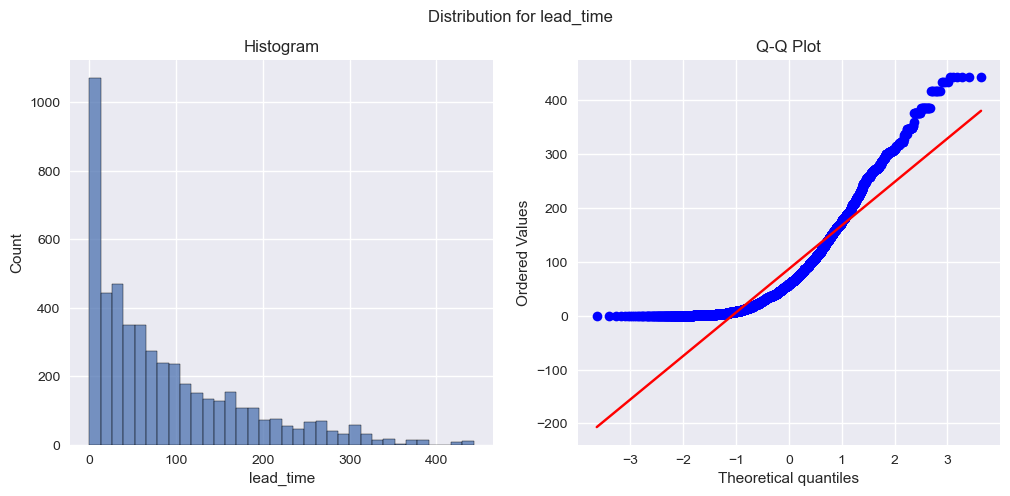

Statistics for the numerical column: lead_time
Skewness: 1.3001470415845846
Shapiro-Wilk test p-value: 3.3582969452470265e-55
p-value is equal or less than 0.05, We reject noramlity in distribution



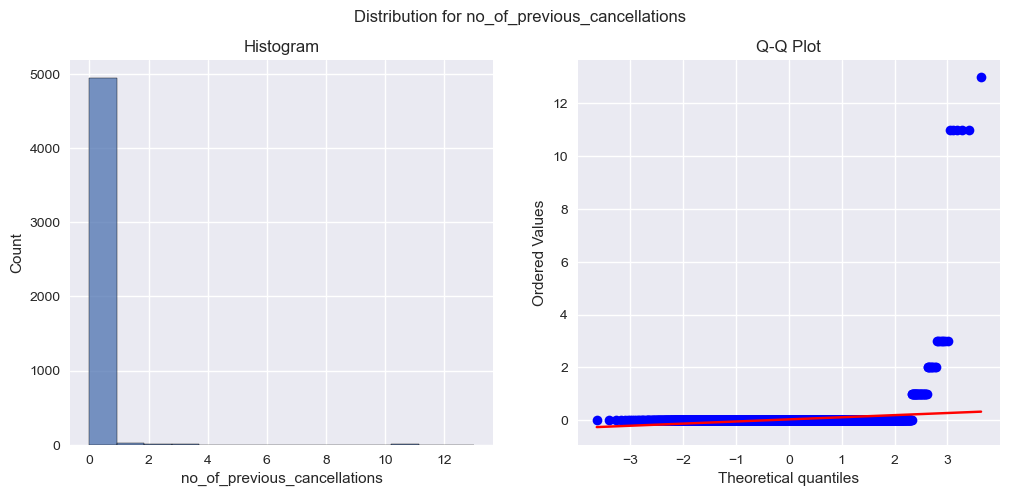

Statistics for the numerical column: no_of_previous_cancellations
Skewness: 23.853956324381304
Shapiro-Wilk test p-value: 5.704773884127103e-95
p-value is equal or less than 0.05, We reject noramlity in distribution



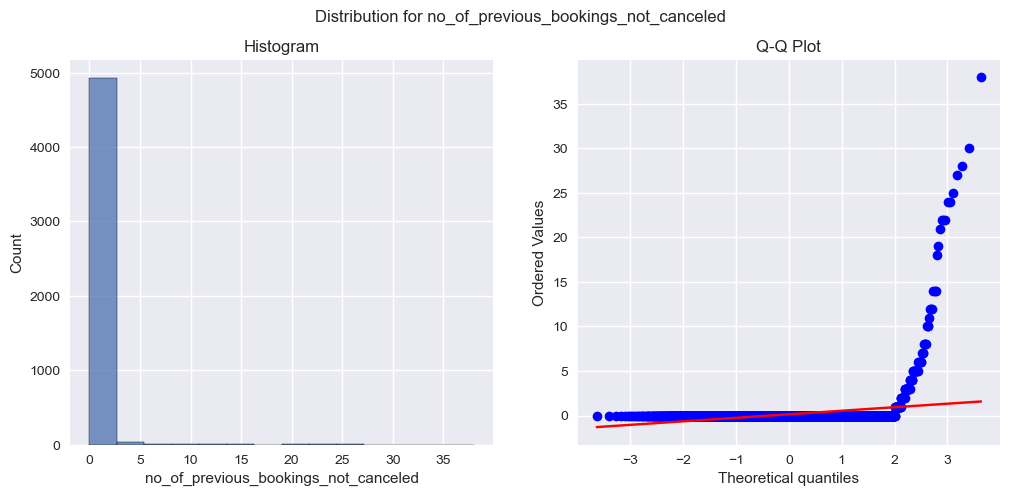

Statistics for the numerical column: no_of_previous_bookings_not_canceled
Skewness: 15.140600160761805
Shapiro-Wilk test p-value: 4.592787725079774e-94
p-value is equal or less than 0.05, We reject noramlity in distribution



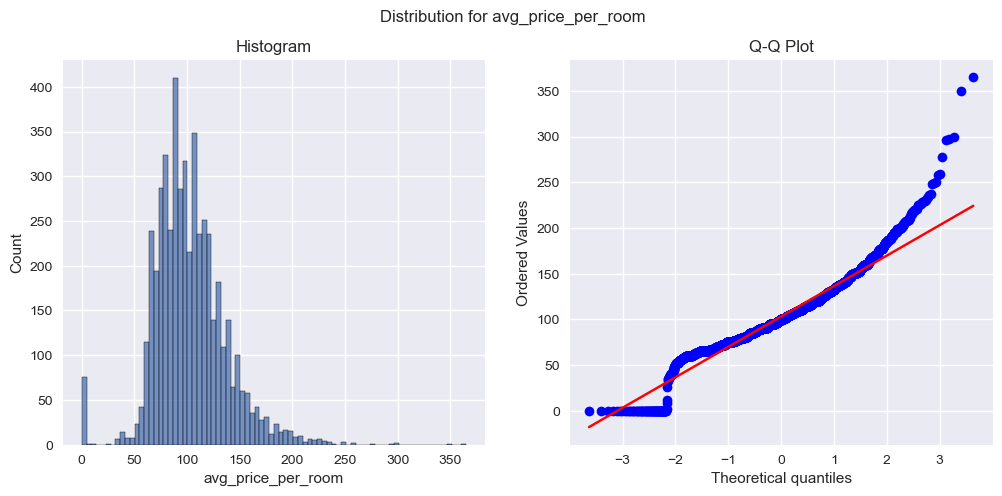

Statistics for the numerical column: avg_price_per_room
Skewness: 0.7108154591158391
Shapiro-Wilk test p-value: 4.1203743896134946e-39
p-value is equal or less than 0.05, We reject noramlity in distribution



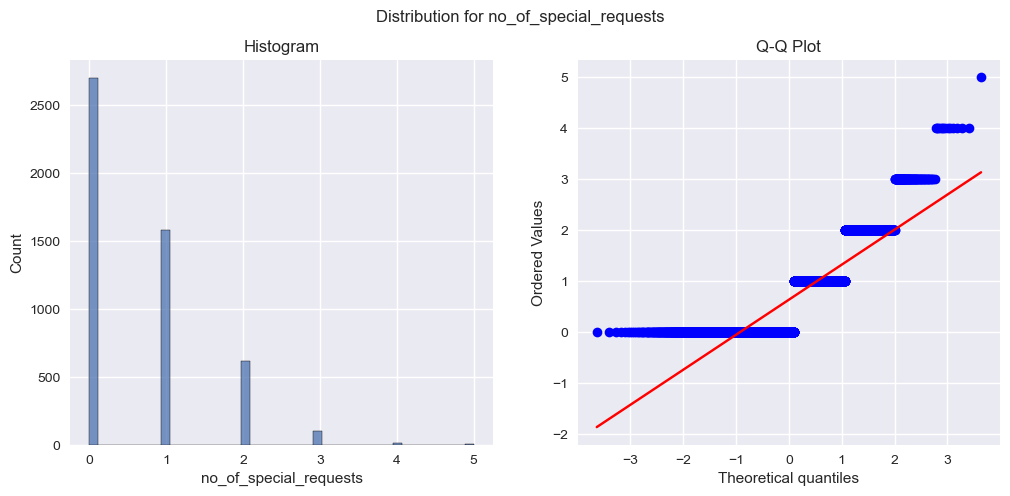

Statistics for the numerical column: no_of_special_requests
Skewness: 1.1419649473261622
Shapiro-Wilk test p-value: 6.172085117419757e-66
p-value is equal or less than 0.05, We reject noramlity in distribution



In [37]:
for col in numerical_features:
    DisplayDistribution(x_train, col)

Based on the above, all numeric features are skewed. Therefore, we will use `PowerTransformer` instead of `StandardScaler`

Note: While `no_of_adults` is the closest to a normal distribution based on the histogram, statistical tests show that it is skewed.

In [38]:
pt = PowerTransformer()

In [39]:
x_train_pp = PowerTransform_Features(x_train_pp, pt, numerical_features)

In [40]:
x_train_pp[numerical_features].sample(n = 5, random_state = random_state)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,lead_time,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
15198,-1.573599,-0.285207,-1.025826,0.689975,0.062852,-0.097451,-0.152316,-0.619777,-0.897358
10571,2.445053,-0.285207,0.531924,-2.163335,0.557560,-0.097451,-0.152316,1.335080,-0.897358
22722,0.261496,-0.285207,-1.025826,0.002240,1.779028,-0.097451,-0.152316,-1.491481,-0.897358
746,2.445053,-0.285207,-1.025826,1.263456,0.154755,-0.097451,-0.152316,0.559885,-0.897358
11548,2.445053,-0.285207,-1.025826,0.002240,1.114536,-0.097451,-0.152316,1.068809,-0.897358


We can see that Power Transformer has transformed the values to continuous numerical values. Lets see if we can compare the before and after power transformation.

In [41]:
x_train[numerical_features].sample(n = 5, random_state = random_state)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,lead_time,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
15198,1,0,0,3,58,0,0,81.00,0
10571,3,0,1,0,103,0,0,151.20,0
22722,2,0,0,2,315,0,0,52.00,0
746,3,0,0,4,65,0,0,122.65,0
11548,3,0,0,2,179,0,0,141.30,0


In [42]:
pd.DataFrame(pt.inverse_transform(x_train_pp[numerical_features]), columns = numerical_features, index = x_train_pp.index).sample(n = 5, random_state = random_state)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,lead_time,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
15198,1.0,0.0,0.0,3.0,58.0,0.0,0.0,81.00,0.0
10571,3.0,0.0,1.0,0.0,103.0,0.0,0.0,151.20,0.0
22722,2.0,0.0,0.0,2.0,315.0,0.0,0.0,52.00,0.0
746,3.0,0.0,0.0,4.0,65.0,0.0,0.0,122.65,0.0
11548,3.0,0.0,0.0,2.0,179.0,0.0,0.0,141.30,0.0


Transformed values when inversely transformed, are similar to the original training dataset `x_train`.

In [43]:
x_train_pp.head()

,required_car_parking_space,repeated_guest,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 1,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,lead_time,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
25629,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0.261496,3.506195,1.261826,-0.876525,-0.505744,-0.097451,-0.152316,1.596265,-0.897358
14473,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0.261496,3.506195,0.531924,-0.876525,0.511475,-0.097451,-0.152316,0.528163,1.443944
23720,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0.261496,-0.285207,-1.025826,0.689975,2.200934,-0.097451,-0.152316,-0.944278,-0.897358
5843,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0.261496,-0.285207,1.261826,1.759741,1.208682,-0.097451,-0.152316,-0.877359,-0.897358
18709,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,-1.573599,-0.285207,-1.025826,0.002240,1.168210,-0.097451,-0.152316,0.761662,-0.897358


In [44]:
x_train_pp.shape

(29020, 27)

In [45]:
x_train_pp.columns

Index(['required_car_parking_space', 'repeated_guest',
       'type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2',
       'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected',
       'room_type_reserved_Room_Type 1', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Aviation',
       'market_segment_type_Complementary', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online',
       'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'lead_time', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests'],
      dtype='object')

Initially, we had 5 categorical features and 9 numerical features, totalling 14 descriptive features. After preprocessing the data with One Hot encoding for categorical variables, and applying Power Transformation to numerical variables, the features increased to 18 encoded categorical features and 9 trasnformed numerical features, resulting in a total of 27 desriptive features.

While these preprocessing steps are required before training the model, the increased number of features may result in higher computational costs, increased model complexity, and a higher risk of overfitting, where some new features may be redundant or not informative.

This is where feature selection comes in.

### <a id = "feature-selection">4.2. Feature Selection<a/>

Feature selection is the process of selecting important features from a dataset that have a strong relationship/correlation and predictive power to the target feature.

By removing redundant or less useful features, this reduces the dimensions of the dataset, making the model training process less complex and therefore, requires less time to build.

In this project, we will be using the `f_classif` library. This statistical test method will help identify features that are useful in predicting the target feature.

We will use graphical representations to analyse the features, and select a couple of features to be used to train the model.

In [46]:
f_stat, p_val = f_classif(x_train_pp, y_train)

In [47]:
feature_selection_df = pd.DataFrame({
    "Feature": x_train_pp.columns,
    "F-Statistic": f_stat,
    "P-Value": p_val
})

feature_selection_df = feature_selection_df.sort_values(by = ["F-Statistic", "P-Value"], ascending = [False, True]).reset_index(drop = True)
feature_selection_df

,Feature,F-Statistic,P-Value
0,lead_time,5985.308907,0.000000e+00
1,no_of_special_requests,2061.919507,0.000000e+00
2,avg_price_per_room,652.351777,2.578022e-142
3,market_segment_type_Corporate,373.825124,9.131787e-83
4,repeated_guest,340.107996,1.634288e-75
5,market_segment_type_Online,332.324870,7.744530e-74
6,no_of_previous_bookings_not_canceled,308.383859,1.114069e-68
7,required_car_parking_space,241.726547,2.738204e-54
8,type_of_meal_plan_Meal Plan 2,239.514179,8.239263e-54
9,no_of_adults,233.107887,2.002399e-52


Lets use MinMaxScaler to scale both `F-Statistic` and `P-Value`, for graphical comparisons across the features.

In [48]:
mms = MinMaxScaler()

feature_selection_scaled_df = feature_selection_df.copy()

feature_selection_scaled_df.loc[:, ["F-Statistic", "P-Value"]] = mms.fit_transform(feature_selection_scaled_df.loc[:, ["F-Statistic", "P-Value"]])
feature_selection_scaled_df

,Feature,F-Statistic,P-Value
0,lead_time,1.000000,0.000000e+00
1,no_of_special_requests,0.344496,0.000000e+00
2,avg_price_per_room,0.108991,2.779919e-142
3,market_segment_type_Corporate,0.062456,9.846942e-83
4,repeated_guest,0.056822,1.762277e-75
5,market_segment_type_Online,0.055522,8.351042e-74
6,no_of_previous_bookings_not_canceled,0.051522,1.201317e-68
7,required_car_parking_space,0.040385,2.952646e-54
8,type_of_meal_plan_Meal Plan 2,0.040016,8.884520e-54
9,no_of_adults,0.038945,2.159217e-52


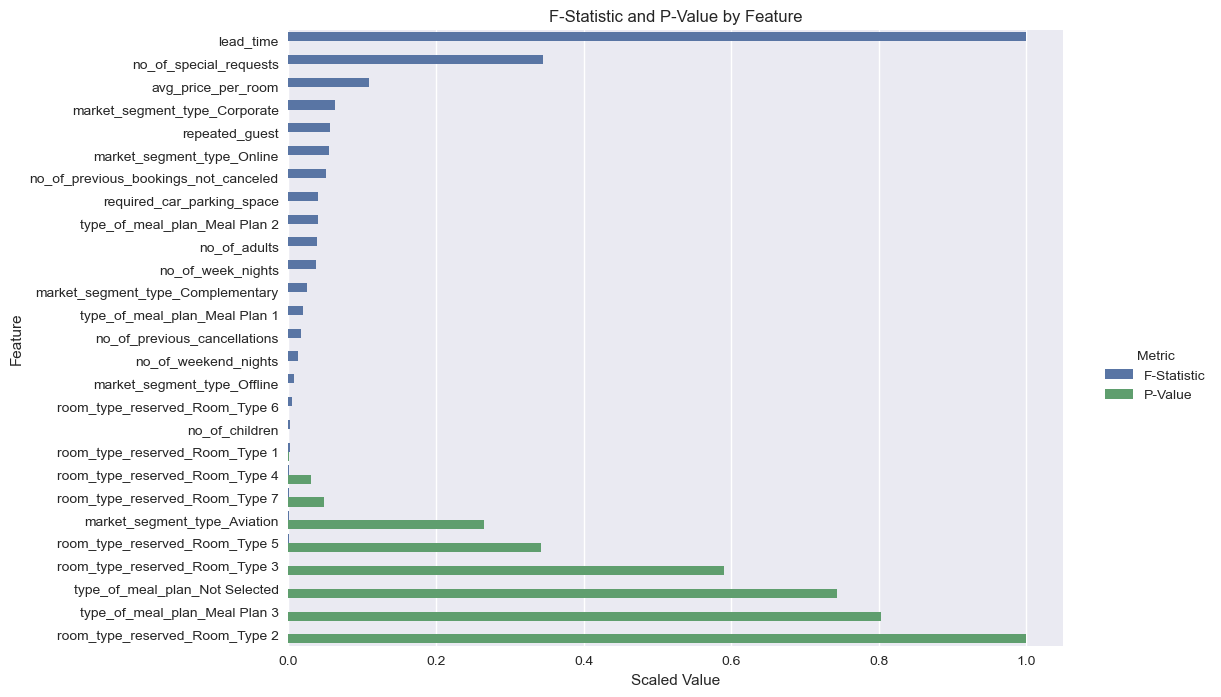

In [49]:
feature_selection_scaled_long_df = feature_selection_scaled_df.melt(id_vars = "Feature", value_vars = ["F-Statistic", "P-Value"],
                                                                    var_name = "Stat_Metric", value_name = "Score")

plt.figure(figsize = (10, 8))
sns.barplot(data = feature_selection_scaled_long_df, x = "Score", y = "Feature", hue = "Stat_Metric", orient = "h")

plt.title("F-Statistic and P-Value by Feature")
plt.xlabel("Scaled Value")
plt.ylabel("Feature")
plt.legend(title = "Metric", bbox_to_anchor = (1.2, 0.5))

plt.show()

In [50]:
feature_selection_df.loc[feature_selection_df["P-Value"] >= 0.05, :]

,Feature,F-Statistic,P-Value
21,market_segment_type_Aviation,1.347611,0.245706
22,room_type_reserved_Room_Type 5,0.997948,0.317816
23,room_type_reserved_Room_Type 3,0.362823,0.546947
24,type_of_meal_plan_Not Selected,0.159569,0.689557
25,type_of_meal_plan_Meal Plan 3,0.105919,0.744841
26,room_type_reserved_Room_Type 2,0.008309,0.927373


`type_of_meal_plan_Meal Plan 3`, `type_of_meal_plan_Not Selected`, `room_type_reserved_Room_Type 2`, `room_type_reserved_Room_Type 3`, `room_type_reserved_Room_Type 5` and `market_segment_type_Aviation` features are found not statistically significant (p-value >= 0.05). This are features that should not be used for modelling.

`lead_time` is by far the feature with the highest F-Statistic, and the results are statistically significant too. This is followed by `no_of_special_requests` and then `avg_price_per_room`. We are definitely going to keep this features for modelling as they offer the most information to the target feature.

We can select the features by 2 methods
- By Threshold (i.e. Accept all features with a F-Statistic score is above a certain threhold value)
- By `SelectKBest`, where we select the top k number of features

In this project, we will use `SelectKBest` and select the top k = 10 number of features. This would help simplify in training.

We can select the features by 2 methods
- By Threshold (i.e. Accept all features with a F-Statistic score is above a certain threhold value)
- By `SelectKBest`, where we select the top k number of features

In [51]:
feature_selector = SelectKBest(score_func = f_classif, k = 10)
feature_selector.fit_transform(x_train_pp, y_train)

selected_columns = list(x_train_pp.columns[feature_selector.get_support()])
selected_columns

['required_car_parking_space',
 'repeated_guest',
 'type_of_meal_plan_Meal Plan 2',
 'market_segment_type_Corporate',
 'market_segment_type_Online',
 'no_of_adults',
 'lead_time',
 'no_of_previous_bookings_not_canceled',
 'avg_price_per_room',
 'no_of_special_requests']

In [52]:
# Just to check that the top 10 found in SelectKBest is the same as what is seen in the feature_selector dataframe
sorted(list(feature_selection_df.loc[:9, "Feature"])) == sorted(selected_columns)

True

Lets select the top 10 features in our training dataset

In [53]:
x_train_pp = x_train_pp.loc[:, selected_columns]
x_train_pp.head()

,required_car_parking_space,repeated_guest,type_of_meal_plan_Meal Plan 2,market_segment_type_Corporate,market_segment_type_Online,no_of_adults,lead_time,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
25629,0,0,0,0,1,0.261496,-0.505744,-0.152316,1.596265,-0.897358
14473,0,0,0,0,1,0.261496,0.511475,-0.152316,0.528163,1.443944
23720,0,0,0,0,0,0.261496,2.200934,-0.152316,-0.944278,-0.897358
5843,0,0,0,0,0,0.261496,1.208682,-0.152316,-0.877359,-0.897358
18709,0,0,0,0,0,-1.573599,1.168210,-0.152316,0.761662,-0.897358


### <a id = "model-fitting-tuning">4.3. Model Fitting & Tuning<a/>

Before we proceed, lets recap on what has been done so far:
1) We removed features that were not helpful for model generalisation
    - `booking_id`: A Unique Identifier with no predictive value
    - All arrival date columns: Unlikely to provide meaningful information for model training
2) We also splitted the dataset with a ratio of 80% training to 20% testing.
    - Training dataset has 29020 observations
    - Testing dataset has 7255 observations
3) For the training dataset, we applied feature transformations
    - One Hot Encoding for Categorical features with multiple unique values
    - Power Transformer for Numerical features to normalise data distributions
4) With the additional features from feature transformation, we conducted feature selection
    - `f_classif` shows us the F-statistic score and p-value for each individual feature
    - Selected the top k = 10 features using `SelectKBest`
  
Moving on the model training, since this is a classification problem, we will look at the following classification algorithms:
- Logistic Regression
- Decision Tree
- Random Forest

We will perform 5-fold Stratified K Fold Cross Validation using `GridSearchCV` and `StratifiedKFold`, which allows us to effectively use most of the training data for both training and evaluation, while ensuring each fold has the same class distribution ratio.

With a classification problem having a slightly imbalanced dataset, we can use `F1-score` as our main evaluating scoring metric. `F1-score` balances out and provides a harmonic mean of both `precision` and `recall`, where `precision` tells us how many positive bookings were correctly predicted, and `recall` shows the number of actual positive cases the model is able to identify.

By being able to use both `precision` and `recall` under `F1-score`, our models will be able to predict booking cancellations in both ends, where each wrongly predicted outcomes can have financial implicated to the hotel business.

In [54]:
cv_method = StratifiedKFold(n_splits = 5, shuffle = True, random_state = random_state)
scoring_method = "f1"

#### Logistic Regression

Logistic Regression is a probabilistic model that can be used for binary classification problems. It works by predicting between two possible class labels or outcomes (in this case is either the booking is cancelled or not cancelled), by estimating the probability that a given observation belongs to a specific class booking label. It uses sigmoid function to return outputs between 0 (Not Cancelled) and 1 (Cancelled).

As part of tuning hyperparameters in models, we will be looking at the hyperparameters below:
- `penalty`: Penalty controls the type of regularisation. Regularisation is used to prevent overfitting
- `C`: The inverse regularisation strength. A smaller C value means stronger regularisation, and a larger C value means weaker regularisation
- `solver`: The algorithm used in Logistic Regression to tune the model weights.

In [55]:
lr_param_grid = [
    {
        "penalty": ["l1", "l2", None],
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "lbfgs"],
    }
]

We can use %%time to see how long each ipynb cell runs.

In [56]:
%%time

lr = GridSearchCV(
    estimator = LogisticRegression(random_state = random_state),
    param_grid = lr_param_grid,
    cv = cv_method,
    scoring = scoring_method,
    verbose = verbose_category
)

lr.fit(x_train_pp, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
CPU times: total: 40.6 s
Wall time: 6.93 s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(random_state=42),
             param_grid=[{'C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'penalty': ['l1', 'l2', None],
                          'solver': ['liblinear', 'lbfgs']}],
             scoring='f1', verbose=1)

In [57]:
lr_cv_results_df = pd.DataFrame(lr.cv_results_).loc[:, ["param_C", "param_penalty", "param_solver", "mean_test_score"]]
lr_cv_results_df = lr_cv_results_df[~lr_cv_results_df["mean_test_score"].isna()]
lr_cv_results_df["param_penalty_solver"] = lr_cv_results_df.apply(lambda x: f"Penalty: {x['param_penalty']} Solver: {x['param_solver']}", axis = 1)
lr_cv_results_df

,param_C,param_penalty,param_solver,mean_test_score,param_penalty_solver
0,0.001,l1,liblinear,0.597486,Penalty: l1 Solver: liblinear
2,0.001,l2,liblinear,0.630533,Penalty: l2 Solver: liblinear
3,0.001,l2,lbfgs,0.603061,Penalty: l2 Solver: lbfgs
5,0.001,None,lbfgs,0.670336,Penalty: None Solver: lbfgs
6,0.010,l1,liblinear,0.652500,Penalty: l1 Solver: liblinear
8,0.010,l2,liblinear,0.654971,Penalty: l2 Solver: liblinear
9,0.010,l2,lbfgs,0.653522,Penalty: l2 Solver: lbfgs
11,0.010,None,lbfgs,0.670336,Penalty: None Solver: lbfgs
12,0.100,l1,liblinear,0.668113,Penalty: l1 Solver: liblinear
14,0.100,l2,liblinear,0.668223,Penalty: l2 Solver: liblinear


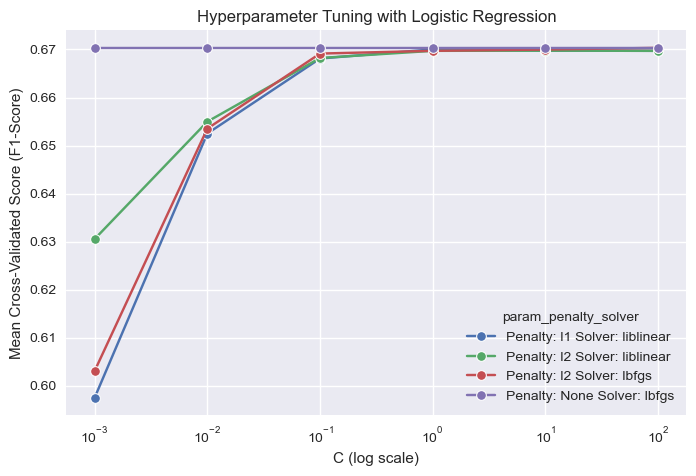

In [58]:
plt.figure(figsize = (8, 5))

sns.lineplot(data = lr_cv_results_df.loc[:, ["param_C", "param_penalty_solver", "mean_test_score"]], 
             x = "param_C", y = "mean_test_score", hue = "param_penalty_solver", marker = "o")

plt.xscale("log")

plt.title("Hyperparameter Tuning with Logistic Regression")
plt.xlabel("C (log scale)")
plt.ylabel("Mean Cross-Validated Score (F1-Score)")

plt.show()

In [59]:
DisplayBestParameterResults(lr)

Best Score: 0.6703358644153271
Best Params: {'C': 0.001, 'penalty': None, 'solver': 'lbfgs'}


Based on the graph above, we can see that using `penalty=None` shows a constant F1-score acroess all values of `C`. This is expected, as `C` would not have any impact the model training when no regularisation is applied.

Applying regularisation with either `l1` or `l2` shows better performance when `C` increases. However, it does not increase any further when C is 1 and more.

The best parameters for Logistic Regression are `C = 0.001`, `penalty = None`, `solver = lbfgs` with a default `random_state = 42` results in a `F1-Score` of 0.670.

In [60]:
selected_lr_model = lr.best_estimator_
selected_lr_model

LogisticRegression(C=0.001, penalty=None, random_state=42)

In [61]:
selected_lr_model.get_params()

{'C': 0.001,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': None,
 'random_state': 42,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

#### Decision Tree

Decision Tree is a machine learning model that splits data based on the values of a feature. Each node segments observations into separate pathways based on a condition or rules on a feature. This split continues for all nodes in the trees until it reaches the final result.

As part of tuning hyperparameters in models, we will be looking at the hyperparameters below:
- `criterion`: Controls the split algorithm
- `max_depth`: The maximum depth of a tree
- `min_samples_split`: The minimum number of samples required before you can split a node
- `min_samples_leaf`: The minimum number of samples in each leaf node
- `max_features`: The number of features taken into account by the Tree

In [62]:
dt_param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 3, 4],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": [None, "sqrt", "log2"]
}

In [63]:
%%time

dt = GridSearchCV(
    estimator = DecisionTreeClassifier(random_state = random_state),
    param_grid = dt_param_grid,
    cv = cv_method,
    scoring = scoring_method,
    verbose = verbose_category
)

dt.fit(x_train_pp, y_train)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
CPU times: total: 1min 30s
Wall time: 1min 30s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [None, 5, 10, 20, 30],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4]},
             scoring='f1', verbose=1)

In [64]:
dt_cv_results_df = pd.DataFrame(dt.cv_results_)
dt_cv_results_df.loc[dt_cv_results_df["param_max_features"].isna(), "param_max_features"] = "None"
dt_cv_results_df.loc[dt_cv_results_df["param_max_depth"].isna(), "param_max_depth"] = "None"

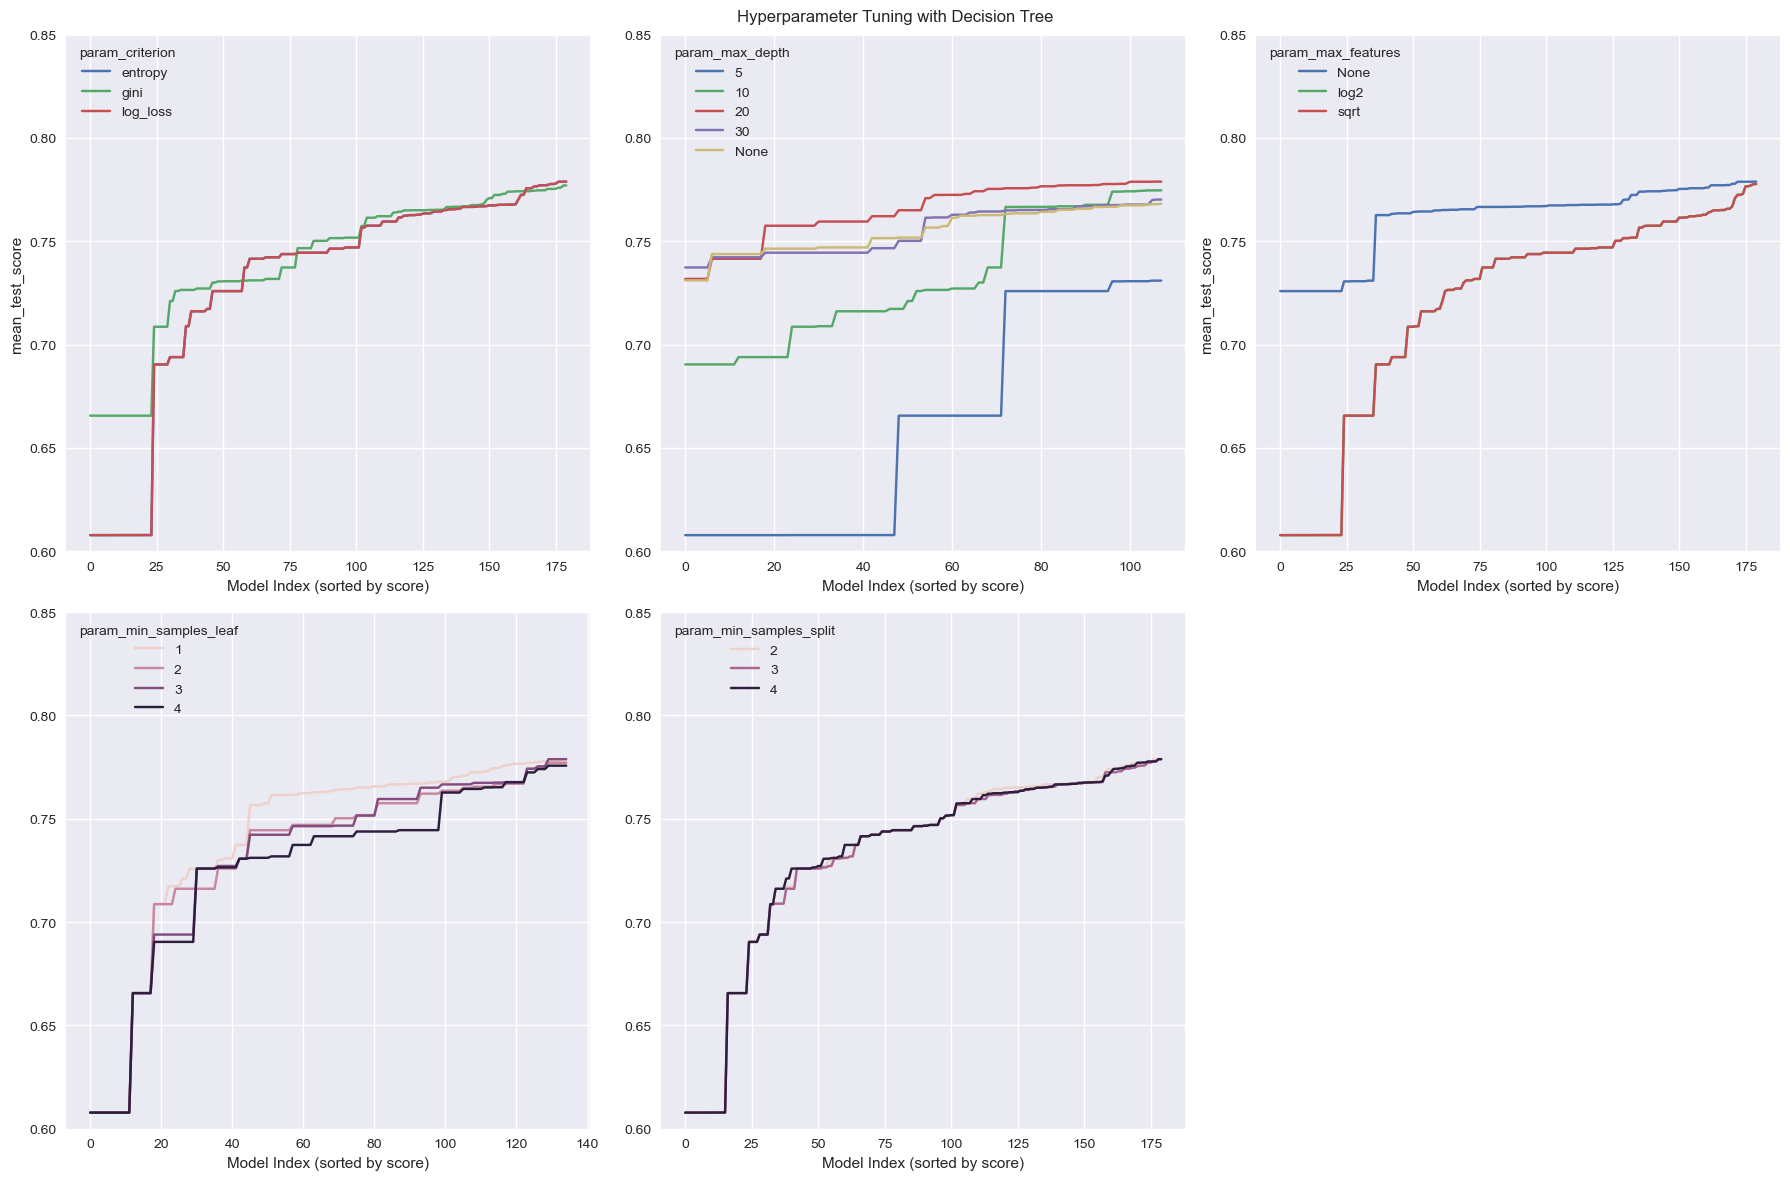

In [65]:
fig, axList = plt.subplots(2, 3, figsize = (18, 12))
axList = axList.ravel()
axList[-1].set_visible(False)

fig.suptitle("Hyperparameter Tuning with Decision Tree")

for i, (ax, param) in enumerate(zip(axList, ["param_criterion", "param_max_depth", "param_max_features", 
                                             "param_min_samples_leaf", "param_min_samples_split"])):
    Display_HP_Tuning_Univariate(dt_cv_results_df, param, ax)

    ax.set_xlabel("Model Index (sorted by score)")
    ax.set_ylim(0.6, 0.85)
    ax.legend(loc = "upper left", title = param)
    
    if i not in [0, 2]:
        ax.set_ylabel("")
    
plt.tight_layout()
plt.show()

Based on the graphs above:
1) While `criterion=gini` was showing better performance in general, `criterion=entropy` and `=log_loss` worked better for most iterations of hyperparameters.
2) `max_depth` has the most influence in model performance, specifically when the Tree is not complex. We can see that the F1-Score increases significantly when the Tree depth increases from 5 to 10. This means that the model is underfitting when the depth is limited. That said, the performances show little difference when `max_depth` is 20 and more. This means a depth of 20 is sufficient to build the model complexity.
3) `max_features=None` show better performances compared to `sqrt` and `log2`. Given that there are 10 features and their high importance as seen from feature selection, reducing the number of features might result in the loss of information that could be used to train the model
4) `min_samples_leaf=1` generally perform better. That said, the lines converge when `min_samples_leaf=2` to `=4`.
5) `min_samples_split` show little or negligible difference when tuning hyperparameter. The selection for such hyperparameters may not be a huge impact for our dataset.

In [66]:
DisplayBestParameterResults(dt)

Best Score: 0.778854150539446
Best Params: {'criterion': 'entropy', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


The best parameters for Decision Tree are `criterion = entropy`, `max_depth = 20`, `max_features = None`, `min_samples_leaf = 1` and `min_samples_split = 2` with a default `random_state = 42` results in a `F1-Score` of 0.779.

In [67]:
selected_dt_model = dt.best_estimator_
selected_dt_model

DecisionTreeClassifier(criterion='entropy', max_depth=20, random_state=42)

In [68]:
selected_dt_model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 20,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

#### Random Forest

Random Forest is an ensemble machine learning method that builds many Decision Trees, and combines their results together to make more accurate and stable predictions. Unlike a single Decision Tree, which may outfit, Random Forest reduces overfitting by averaging (regression mode) or selecting the most occurance class (classification model) from multiple Decision Trees trained on different parts of the dataset.

As part of tuning hyperparameters in models, we will be looking at the hyperparameters below:
- `n_estimators`: The number of Decision Trees in the Random Forest algorithm
- `max_depth`: The maximum depth of a tree
- `min_samples_split`: The minimum number of samples required before you can split a node
- `min_samples_leaf`: The minimum number of samples in each leaf node

Do note that we will not be running too many hyperparameters here, as this would take a long time to train

In [69]:
rf_param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 3, 4],
    "min_samples_leaf": [1, 2, 3, 4]
}

In [70]:
%%time

rf = GridSearchCV(
    estimator = RandomForestClassifier(random_state = random_state),
    param_grid = rf_param_grid,
    cv = cv_method,
    scoring = scoring_method,
    verbose = verbose_category
)

rf.fit(x_train_pp, y_train)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
CPU times: total: 18min 15s
Wall time: 18min 19s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 5, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [50, 100, 150]},
             scoring='f1', verbose=1)

In [71]:
rf_cv_results_df = pd.DataFrame(rf.cv_results_)
rf_cv_results_df.loc[rf_cv_results_df["param_max_depth"].isna(), "param_max_depth"] = "None"

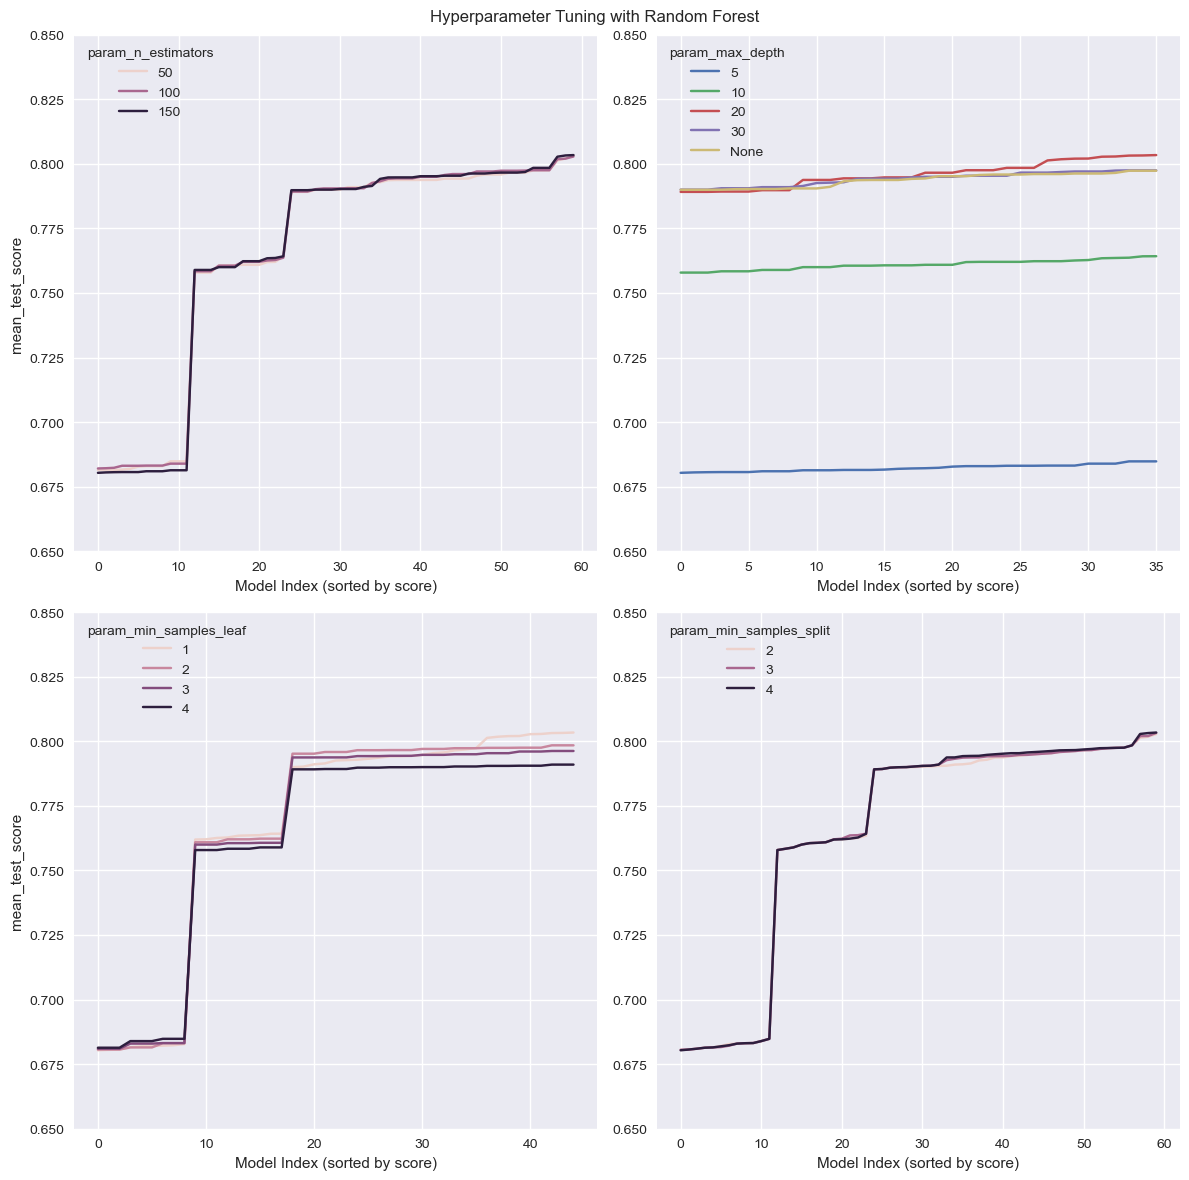

In [72]:
fig, axList = plt.subplots(2, 2, figsize = (12, 12))
axList = axList.ravel()

fig.suptitle("Hyperparameter Tuning with Random Forest")

for i, (ax, param) in enumerate(zip(axList, ["param_n_estimators", "param_max_depth", 
                                             "param_min_samples_leaf", "param_min_samples_split"])):
    Display_HP_Tuning_Univariate(rf_cv_results_df, param, ax)

    ax.set_xlabel("Model Index (sorted by score)")
    ax.set_ylim(0.65, 0.85)
    ax.legend(loc = "upper left", title = param)
    
    if i not in [0, 2]:
        ax.set_ylabel("")
    
plt.tight_layout()
plt.show()

Based on the graphs above:
1) The number of trees from `n_estimators` did not differ much in performance as it converges for most iterations of hyperparameters. We can build with `n_estimators=50` if we want faster training and prediction, or increase to `n_estimators=150` if we want a more stable prediction result.
2) Similar to Decision Trees, `max_depth` has the most influence in model performance, specifically when the Tree is not complex. We can see that the F1-Score increases significantly when the Tree depth increases from 5 to 10. This means that the model is underfitting when the depth is limited. That said, the performances show no difference when `max_depth` is 20 and more. This means a depth of 20 is sufficient to build the model complexity. Note: The slight spike could be due to other hyperparameters.
3) `min_samples_leaf=1` generally perform better.
4) Similar to Decision Trees, `min_samples_split` show little or negligible difference when tuning hyperparameter. The selection for such hyperparameters may not be a huge impact for our dataset.

In [73]:
DisplayBestParameterResults(rf)

Best Score: 0.8033548450412674
Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 150}


The best parameters for Random Forest are `n_estimators = 150`, `max_depth = 20`, `max_depth = 20`, `min_samples_leaf = 1` and `min_samples_split = 4` with a default `random_state = 42` results in a `F1-Score` of 0.803.

In [74]:
selected_rf_model = rf.best_estimator_
selected_rf_model

RandomForestClassifier(max_depth=20, min_samples_split=4, n_estimators=150,
                       random_state=42)

In [75]:
selected_rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 20,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 150,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

### <a id = "neural-network-model-fitting-tuning">4.4. Neural Network Model Fitting & Tuning<a/>

Neural Networks are modern machine learning models that were inspired by the way our brain works and processes information.

A basic Neural Network is made up of layers with units (or neurons) that are connected to each other. These networks can find non-linear patterns which allows it to learn complex relationships between the features to the target feature.

There are 3 different types of layers. Input, Hidden and Output layers. An input layer consists of each individual feature as a neuron, and takes in the value of each observation. This is passed into the hidden layers, where each neuron in the hidden layer takes in the inputs from all connected neurons in the previous layer and performs transformations using weighted connections, biases and activation functions. At the end, the final layer which is an output layer outputs the results in a single node (in binary classification), with a sigmoid activation function.

During training, the network fine tunes its weights and biases through a process called backpropagation. This works by minimising the difference between the predicted and actual values using gradient descent.

The Neural Network framework is powerful for capturing hidden patterns in datasets, where simpler and traditional machine learning models may fail to capture the complexity of the problem.

In this project, we design and train neural network models, but with some limitations
1) No Cross Validation<br>
To reduce training time, we will opt for a hold-out set using `train_test_split` to create a validation dataset from the training dataset
2) No Grid Search<br>
Since we are tuning each hyperparameter individually, we will not be using `GridSearchCV`. This also reduces the computational time needed to train and tune the hyperparameters.

We also look into tuning hyperparameters, including:
1) Learning Rate<br>
How much the model updates the weights and biases while training
2) Activation Function<br>
The transformation algorithm or function at each neuron. This value would be the output of the neurons.
3) Number of Units in each Hidden Layer<br>
The number of neurons at each hidden layer.
4) Dropout Rate<br>
A regularisation technique to prevent overfitting by disabling the neuron from being activated
5) Epoch and Batch Size<br>
The training size and number of times the model trains on the dataset

In [76]:
x_train_pp_split, x_val_pp_split, y_train_split, y_val_split = train_test_split(
    x_train_pp, y_train, test_size = 0.2, random_state = random_state, stratify = y_train
)

We will also be creating a neural network with 2 hidden layers, and specify the default hyperparameters values. This will be used to compare the model performances for each hyperparameter tuned.

In [77]:
default_input_dim = 10
default_learning_rate = 1e-02
default_layer1_units = 4
default_layer2_units = 4
default_layer1_dropout_rate = 0.05
default_layer2_dropout_rate = 0.05
default_layer1_activation = "relu"
default_layer2_activation = "relu"

default_epoch = 50
default_batch_size = 32

For every ipynb cell training Neural Network Model, we need to run `set_seed()` to ensure that the neural network is also trained with the same seed or state.

In [78]:
%%time

set_seed()

model = model_factory(input_dim = default_input_dim, learning_rate = default_learning_rate,
                      layer1_units = default_layer1_units, layer2_units = default_layer2_units, 
                      layer1_dropout_rate = default_layer1_dropout_rate, layer2_dropout_rate = default_layer2_dropout_rate, 
                      layer1_activation = default_layer1_activation, layer2_activation = default_layer2_activation)

history = model.fit(x_train_pp_split, y_train_split,
                    epochs = default_epoch, batch_size = default_batch_size,
                    verbose = verbose_category, shuffle = True,
                    validation_data = (x_val_pp_split, y_val_split))

Epoch 1/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6859 - loss: 0.6120 - val_accuracy: 0.7238 - val_loss: 0.5508
Epoch 2/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7285 - loss: 0.5383 - val_accuracy: 0.7576 - val_loss: 0.4937
Epoch 3/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7664 - loss: 0.4895 - val_accuracy: 0.7931 - val_loss: 0.4616
Epoch 4/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7799 - loss: 0.4707 - val_accuracy: 0.7993 - val_loss: 0.4487
Epoch 5/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7843 - loss: 0.4614 - val_accuracy: 0.8044 - val_loss: 0.4422
Epoch 6/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7872 - loss: 0.4562 - val_accuracy: 0.8091 - val_loss: 0.4371
Epoch 7/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7920 - loss: 0.4484 - val_accuracy: 0.8151 - val_loss: 0.4331
Epoch 8/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7963 - loss: 0.4448 - val_accuracy: 0.

We can analyse the training process by looking at the history.

In [79]:
hist_df = pd.DataFrame(history.history)

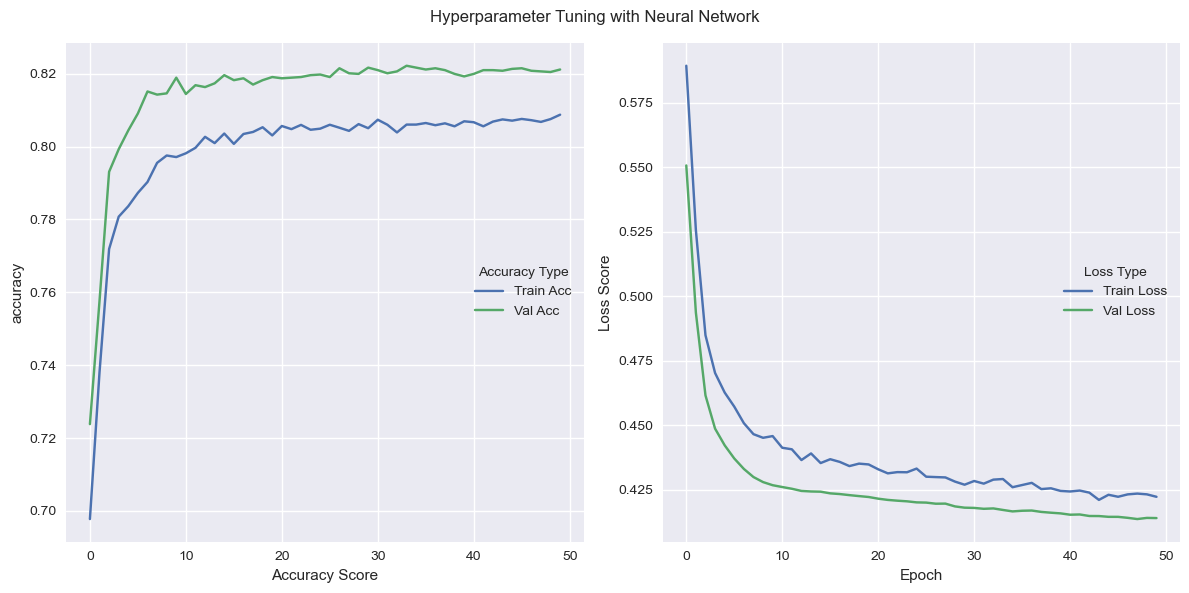

In [80]:
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize = (12, 6))

fig.suptitle("Hyperparameter Tuning with Neural Network")

sns.lineplot(data = hist_df, x = hist_df.index, y = "accuracy", label = "Train Acc", ax = ax_acc)
sns.lineplot(data = hist_df, x = hist_df.index, y = "val_accuracy", label = "Val Acc", ax = ax_acc)

sns.lineplot(data = hist_df, x = hist_df.index, y = "loss", label = "Train Loss", ax = ax_loss)
sns.lineplot(data = hist_df, x = hist_df.index, y = "val_loss", label = "Val Loss", ax = ax_loss)

ax_acc.set_xlabel("Epoch")
ax_acc.set_xlabel("Accuracy Score")
ax_acc.legend(loc = "center right", title = "Accuracy Type")

ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss Score")
ax_loss.legend(loc = "center right", title = "Loss Type")

plt.tight_layout()
plt.show()

Using the default parameters, we can see that our Neural Network model is able to train well with the dataset, with a 0.8 accuracy score and < 0.425 error loss score for both training and validation datasets. Lets see if we can make it stronger by tuning the hyperparameters.

#### Hyperparamter Tuning

##### Learning Rate

Learning Rate controls how much the neural network model weights are updated during the training process. A learning rate that is high may cause the model to converge too fast, resulting in a suboptimal model. A learning rate that is too small would slows down the learning process, causing the model to take a longer time to go down the gradient and improve in performance, or fail to get out of the local minima.

We will be testing a few learning rates `0.00001`,`0.0001`, `0.001`, `0.01` and `0.1`. Each model will be trained using the default hyperparameters specified earlier to ensure consistency.

In [81]:
%%time

learning_rate_list = [1e-05, 1e-04, 1e-03, 1e-02, 1e-01]
history_list = []

set_seed()

for tuning_learning_rate in learning_rate_list:
    model = model_factory(input_dim = default_input_dim, learning_rate = tuning_learning_rate,
                          layer1_units = default_layer1_units, layer2_units = default_layer2_units, 
                          layer1_dropout_rate = default_layer1_dropout_rate, layer2_dropout_rate = default_layer2_dropout_rate, 
                          layer1_activation = default_layer1_activation, layer2_activation = default_layer2_activation)
    
    history = model.fit(x_train_pp_split, y_train_split,
                        epochs = default_epoch, batch_size = default_batch_size,
                        verbose = verbose_category, shuffle = True,
                        validation_data = (x_val_pp_split, y_val_split))
    
    history_list.append(history)

Epoch 1/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6546 - loss: 0.6575 - val_accuracy: 0.6558 - val_loss: 0.6561
Epoch 2/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6530 - loss: 0.6572 - val_accuracy: 0.6564 - val_loss: 0.6557
Epoch 3/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6527 - loss: 0.6563 - val_accuracy: 0.6573 - val_loss: 0.6553
Epoch 4/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6543 - loss: 0.6566 - val_accuracy: 0.6582 - val_loss: 0.6549
Epoch 5/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6505 - loss: 0.6574 - val_accuracy: 0.6585 - val_loss: 0.6545
Epoch 6/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6528 - loss: 0.6561 - val_accuracy: 0.6587 - val_loss: 0.6540
Epoch 7/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6589 - loss: 0.6540 - val_accuracy: 0.6595 - val_loss: 0.6536
Epoch 8/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6542 - loss: 0.6549 - val_accuracy: 0.

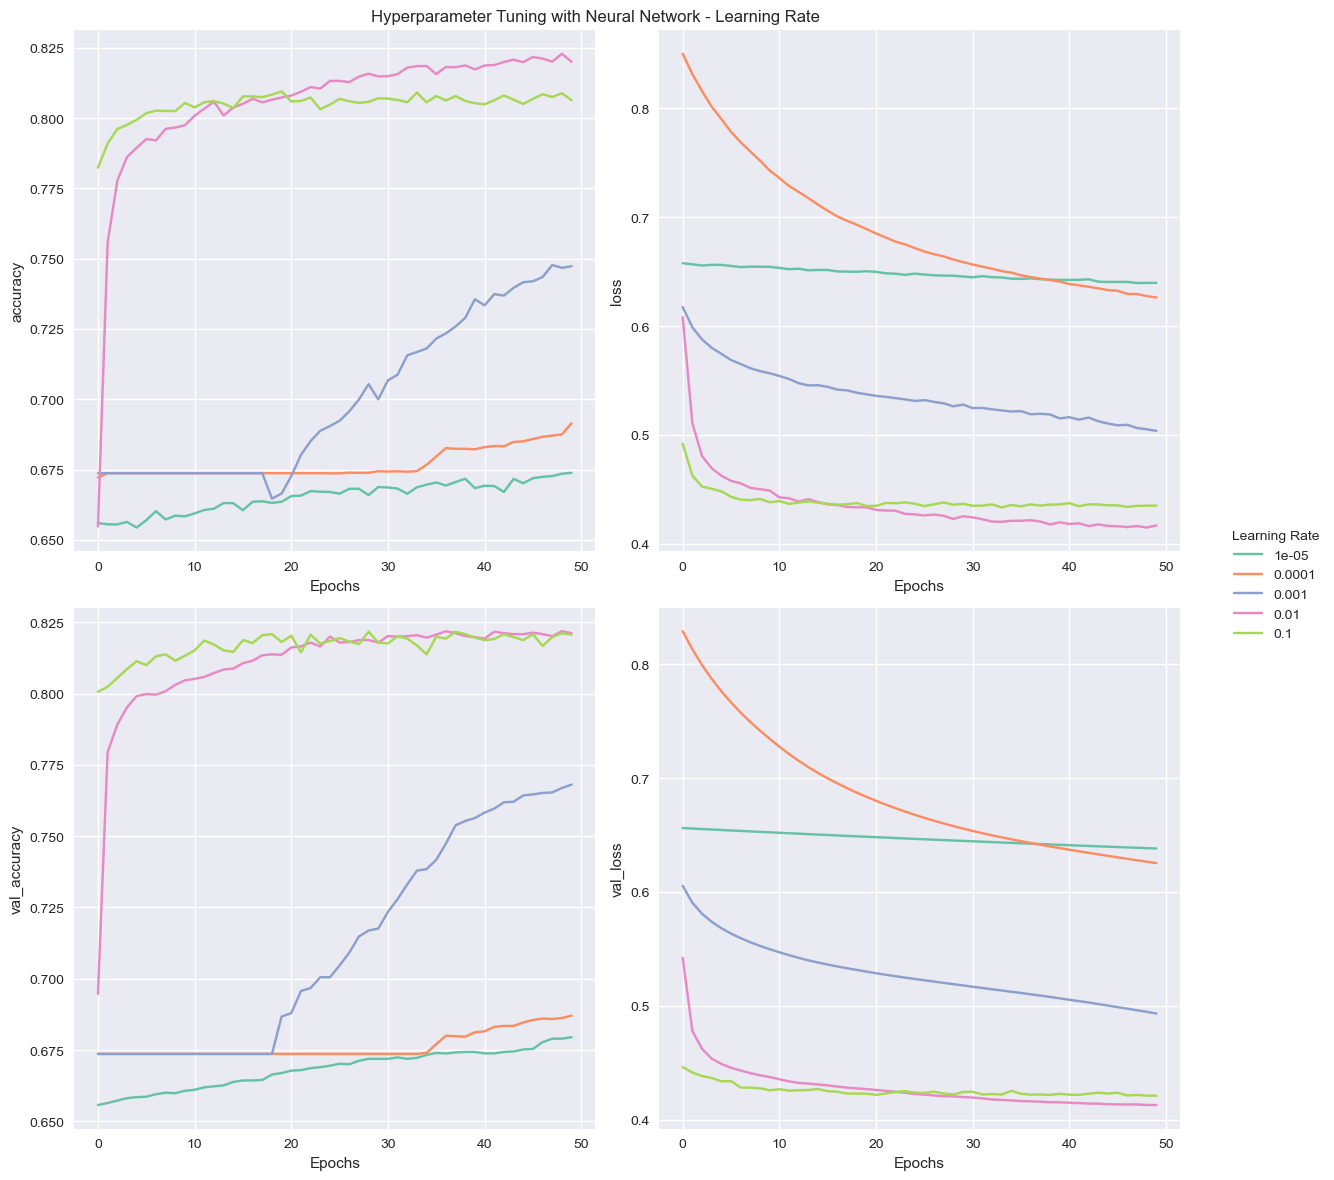

In [82]:
Display_NN_HP_Tuning(history_list, "Learning Rate", hyperparam_values = learning_rate_list)

The training and validation accuracy/loss plots show that the `learning rate = 0.01` produced the best results. Learning Rate that was too small showed low performances and very slow improvements. Setting learning rate to `0.01` or `0.1` works well, and in this case, we will be using `learning rate = 0.01`.

##### Activation Function

Activation functions introduces non-linearity into the Neural Network model, allowing it to learn non-linear and more complex patterns.

For hidden layers, we will be looking at using `relu` or `tanh`
- `relu`: Rectified Linear Unit, where it outputs 0 for inputs 0 or less (negative), and outputs itself if more than 0 (positive)
- `tanh`: Outputs between -1 and 1, which works well in balancing inputs

In [83]:
%%time

layer1_activation_list = ["relu", "tanh"]
layer2_activation_list = ["relu", "tanh"]
history_list = []

set_seed()

for tuning_layer1_activation in layer1_activation_list:
    for tuning_layer2_activation in layer2_activation_list:
        model = model_factory(input_dim = default_input_dim, learning_rate = default_learning_rate,
                              layer1_units = default_layer1_units, layer2_units = default_layer2_units, 
                              layer1_dropout_rate = default_layer1_dropout_rate, layer2_dropout_rate = default_layer2_dropout_rate, 
                              layer1_activation = tuning_layer1_activation, layer2_activation = tuning_layer2_activation)
        
        history = model.fit(x_train_pp_split, y_train_split,
                            epochs = default_epoch, batch_size = default_batch_size,
                            verbose = verbose_category, shuffle = True,
                            validation_data = (x_val_pp_split, y_val_split))
        
        history_list.append(history)

Epoch 1/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6859 - loss: 0.6120 - val_accuracy: 0.7238 - val_loss: 0.5508
Epoch 2/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7285 - loss: 0.5383 - val_accuracy: 0.7576 - val_loss: 0.4937
Epoch 3/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7664 - loss: 0.4895 - val_accuracy: 0.7931 - val_loss: 0.4616
Epoch 4/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7799 - loss: 0.4707 - val_accuracy: 0.7993 - val_loss: 0.4487
Epoch 5/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7843 - loss: 0.4614 - val_accuracy: 0.8044 - val_loss: 0.4422
Epoch 6/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7872 - loss: 0.4562 - val_accuracy: 0.8091 - val_loss: 0.4371
Epoch 7/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7920 - loss: 0.4484 - val_accuracy: 0.8151 - val_loss: 0.4331
Epoch 8/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7963 - loss: 0.4448 - val_accuracy: 0.

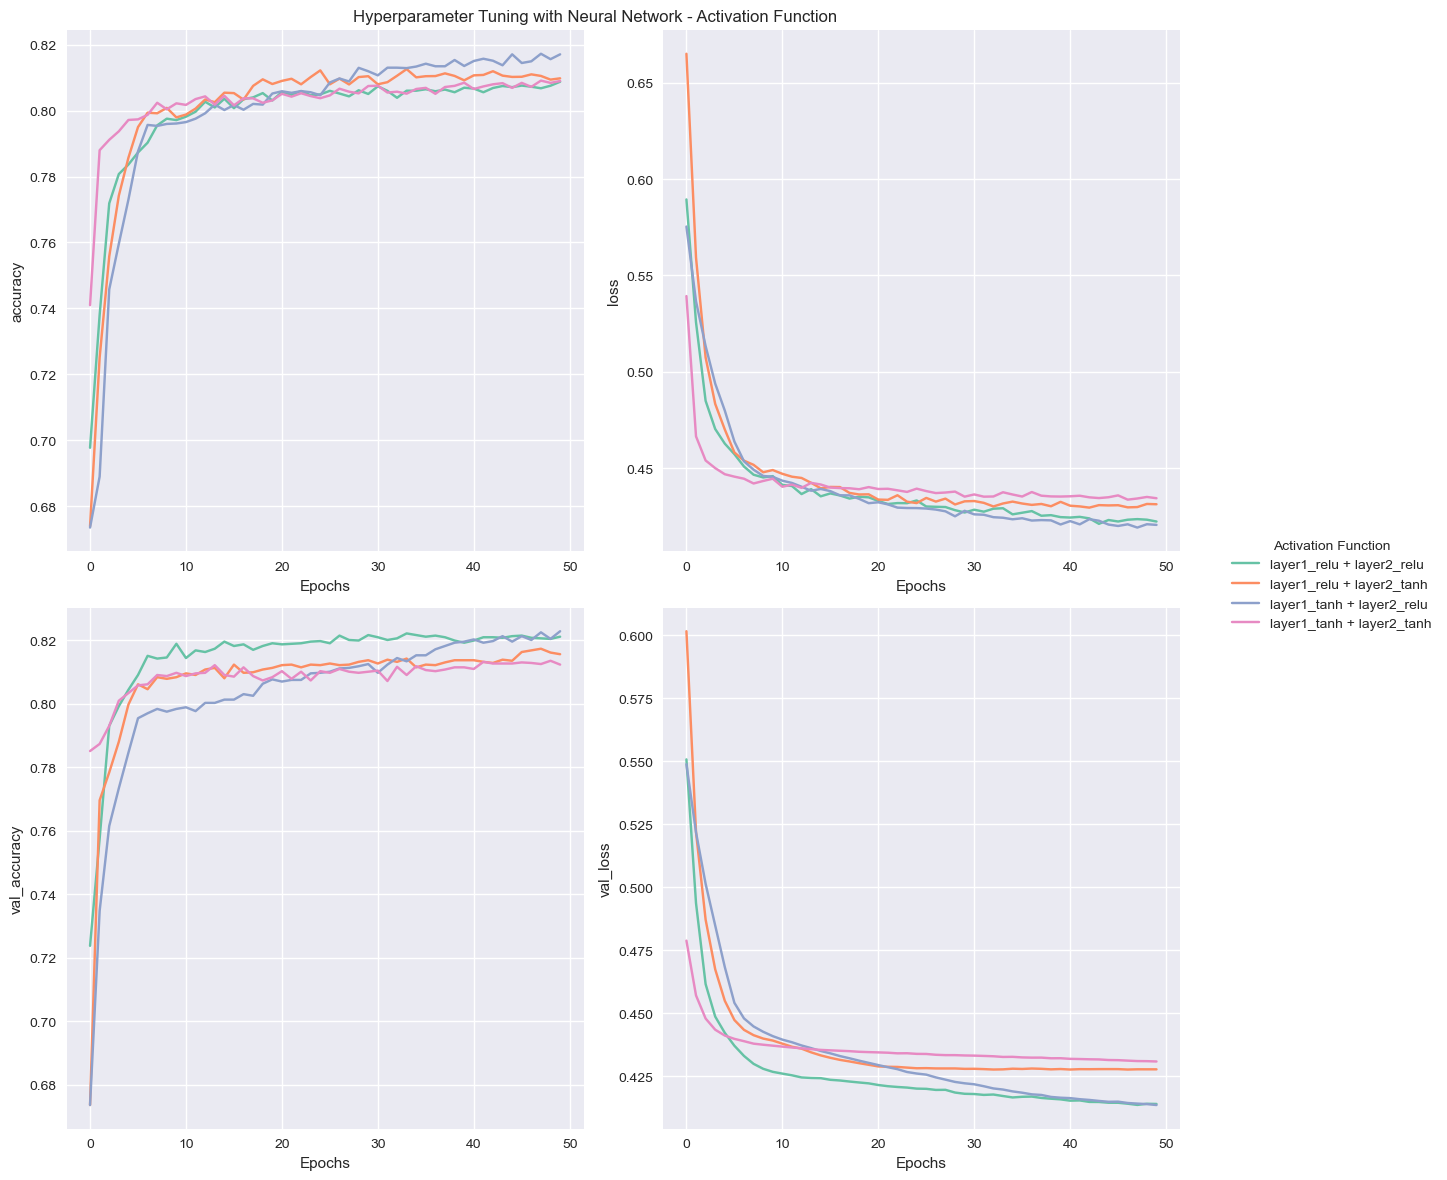

In [84]:
Display_NN_HP_Tuning(history_list, "Activation Function", 
                     hyperparam_values = ["layer1_relu + layer2_relu", "layer1_relu + layer2_tanh", 
                                          "layer1_tanh + layer2_relu", "layer1_tanh + layer2_tanh"])

The training and validation accuracy/loss plots show that the `layer 1's activation function = "tanh"` and `layer 2's activation function = "relu"` produced the best results. Having both activation functions as `tanh` showed the best results initally, but was eventually outclassed by the rest as the number of epochs increased.

In this case, we will be using `layer 1's activation function = "tanh"` and `layer 2's activation function = "relu"`

##### Number of Units in each Hidden Layer

This hyperparameter states the number of neurons in each hidden layer. The idea is that having more units can capture more complex data relationships.

With 2 hidden layers, we try out with having either 4 or 8 neurons in each layer.

In [85]:
%%time

layer1_units_list = [4, 8]
layer2_units_list = [4, 8]
history_list = []

set_seed()

for tuning_layer1_units in layer1_units_list:
    for tuning_layer2_units in layer2_units_list:
        model = model_factory(input_dim = default_input_dim, learning_rate = default_learning_rate,
                              layer1_units = tuning_layer1_units, layer2_units = tuning_layer2_units, 
                              layer1_dropout_rate = default_layer1_dropout_rate, layer2_dropout_rate = default_layer2_dropout_rate, 
                              layer1_activation = default_layer1_activation, layer2_activation = default_layer2_activation)
        
        history = model.fit(x_train_pp_split, y_train_split,
                            epochs = default_epoch, batch_size = default_batch_size,
                            verbose = verbose_category, shuffle = True,
                            validation_data = (x_val_pp_split, y_val_split))
        
        history_list.append(history)

Epoch 1/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6859 - loss: 0.6120 - val_accuracy: 0.7238 - val_loss: 0.5508
Epoch 2/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7285 - loss: 0.5383 - val_accuracy: 0.7576 - val_loss: 0.4937
Epoch 3/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7664 - loss: 0.4895 - val_accuracy: 0.7931 - val_loss: 0.4616
Epoch 4/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7799 - loss: 0.4707 - val_accuracy: 0.7993 - val_loss: 0.4487
Epoch 5/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7843 - loss: 0.4614 - val_accuracy: 0.8044 - val_loss: 0.4422
Epoch 6/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7872 - loss: 0.4562 - val_accuracy: 0.8091 - val_loss: 0.4371
Epoch 7/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7920 - loss: 0.4484 - val_accuracy: 0.8151 - val_loss: 0.4331
Epoch 8/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7963 - loss: 0.4448 - val_accuracy: 0.

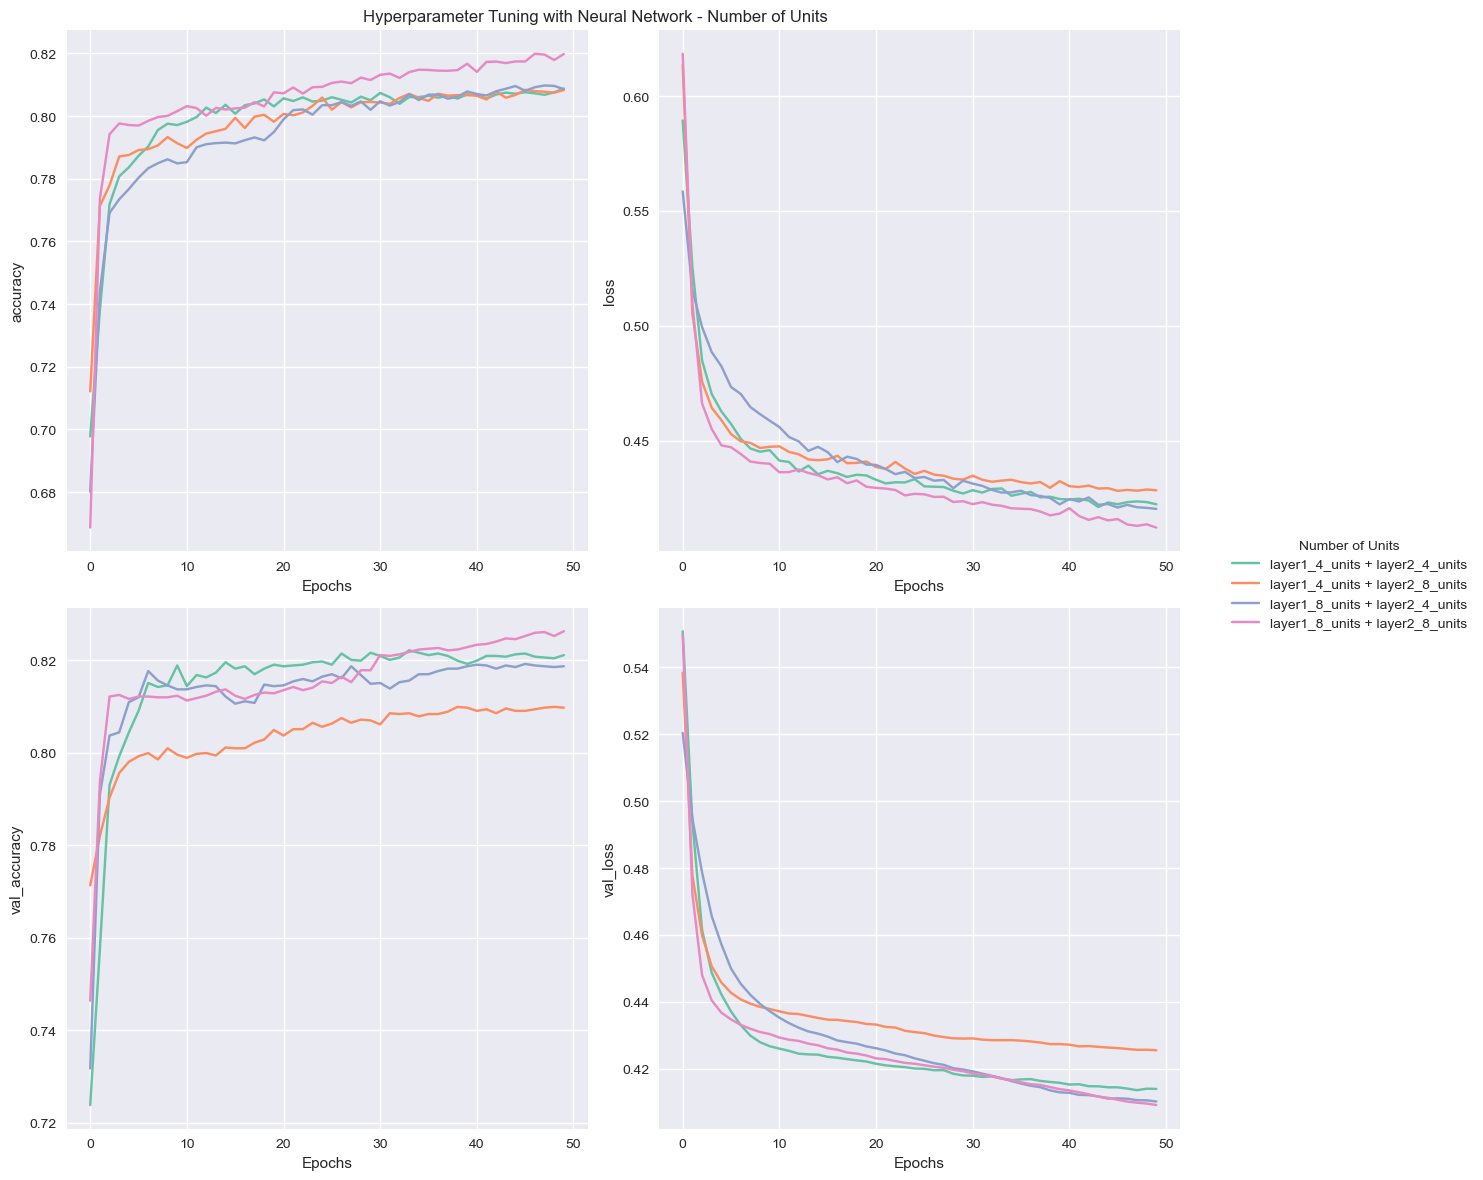

In [86]:
Display_NN_HP_Tuning(history_list, "Number of Units", 
                     hyperparam_values = ["layer1_4_units + layer2_4_units", "layer1_4_units + layer2_8_units", 
                                          "layer1_8_units + layer2_4_units", "layer1_8_units + layer2_8_units"])

The training and validation accuracy/loss plots show that the performance improves when increasing the number of neurons in each hidden layer. It also shows that increaing the number of neurons in the first hidden layer has more impact in performance than incrasing the number of neurons in the second hidden layer.

In this case, we will be using 8 neurons in both hidden layers.

##### Dropout Rate

As part of regularisation, dropout randomly disables neurons during training to prevent overfitting.

As part of having dropouts, we will be testing with 0.05 and 0.1 for both hidden layers.

In [87]:
%%time

layer1_dropout_list = [0.05, 0.1]
layer2_dropout_list = [0.05, 0.1]
history_list = []

set_seed()

for tuning_layer1_dropout_rate in layer1_dropout_list:
    for tuning_layer2_dropout_rate in layer2_dropout_list:
        model = model_factory(input_dim = default_input_dim, learning_rate = default_learning_rate,
                              layer1_units = default_layer1_units, layer2_units = default_layer2_units, 
                              layer1_dropout_rate = tuning_layer1_dropout_rate, layer2_dropout_rate = tuning_layer2_dropout_rate, 
                              layer1_activation = default_layer1_activation, layer2_activation = default_layer2_activation)
        
        history = model.fit(x_train_pp_split, y_train_split,
                            epochs = default_epoch, batch_size = default_batch_size,
                            verbose = verbose_category, shuffle = True,
                            validation_data = (x_val_pp_split, y_val_split))
        
        history_list.append(history)

Epoch 1/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6859 - loss: 0.6120 - val_accuracy: 0.7238 - val_loss: 0.5508
Epoch 2/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7285 - loss: 0.5383 - val_accuracy: 0.7576 - val_loss: 0.4937
Epoch 3/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7664 - loss: 0.4895 - val_accuracy: 0.7931 - val_loss: 0.4616
Epoch 4/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7799 - loss: 0.4707 - val_accuracy: 0.7993 - val_loss: 0.4487
Epoch 5/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7843 - loss: 0.4614 - val_accuracy: 0.8044 - val_loss: 0.4422
Epoch 6/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7872 - loss: 0.4562 - val_accuracy: 0.8091 - val_loss: 0.4371
Epoch 7/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7920 - loss: 0.4484 - val_accuracy: 0.8151 - val_loss: 0.4331
Epoch 8/50
726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7963 - loss: 0.4448 - val_accuracy: 0.

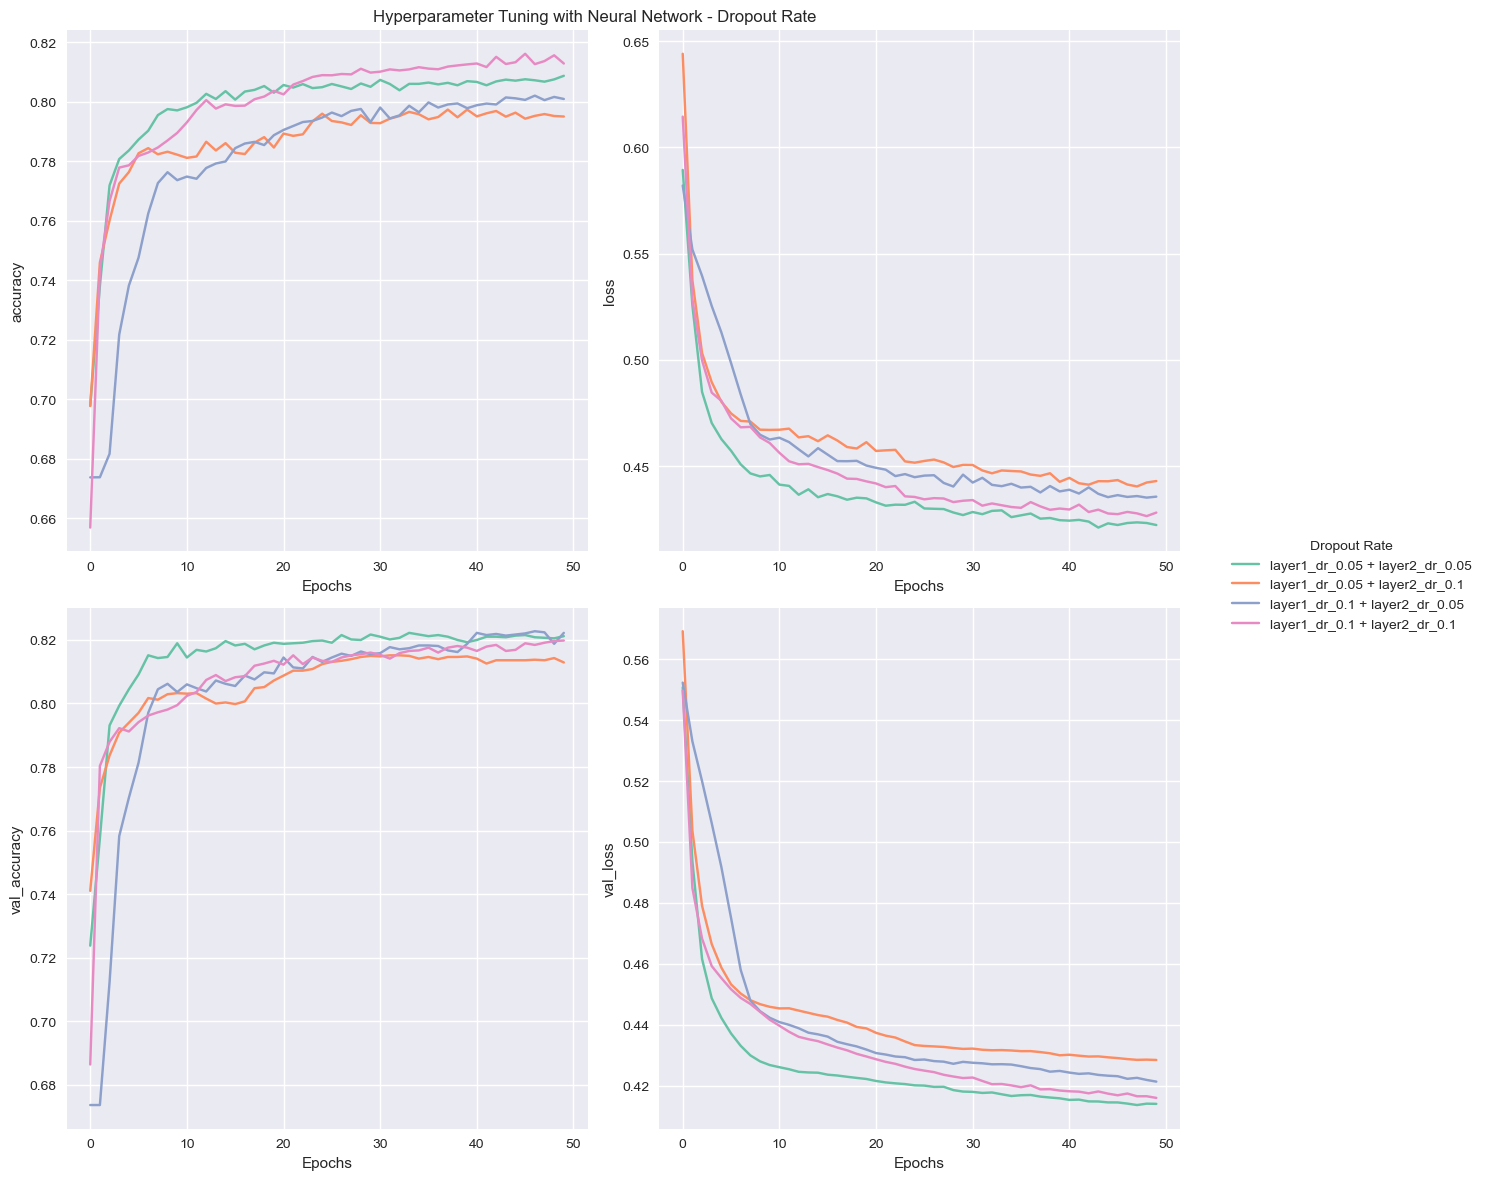

In [88]:
Display_NN_HP_Tuning(history_list, "Dropout Rate", 
                     hyperparam_values = ["layer1_dr_0.05 + layer2_dr_0.05", "layer1_dr_0.05 + layer2_dr_0.1", 
                                          "layer1_dr_0.1 + layer2_dr_0.05", "layer1_dr_0.1 + layer2_dr_0.1"])

The training and validation accuracy/loss plots show that having a lower dropout improves performance.

In this case, we will be using `dropout = 0.05` for both hidden layers

##### Epoch and Batch Size

Epoch refers to the number of times the model is trained on the dataset. With more epoch, the dataset would undergo more training, but require more computational time to process.

Batch Size refers to the number of samples or observations seen by the model during each iteration of training and updating weights. With a higher batch size, the model trains faster but may lead to overfitting, while lower batch size require more time to train, but lead to better generalisation.

We will be testing out epoch sizes of 25 and 50, and batch sizes of 16 and 32.

In [89]:
%%time

set_seed()
epochs_list = [25, 50]
batch_size_list = [16, 32]

history_list = []

for tuning_epoch in epochs_list:
    for tuning_batch_size in batch_size_list:
        model = model_factory(input_dim = default_input_dim, learning_rate = default_learning_rate,
                              layer1_units = default_layer1_units, layer2_units = default_layer2_units, 
                              layer1_dropout_rate = default_layer1_dropout_rate, layer2_dropout_rate = default_layer2_dropout_rate, 
                              layer1_activation = default_layer1_activation, layer2_activation = default_layer2_activation)
        
        history = model.fit(x_train_pp_split, y_train_split,
                            epochs = tuning_epoch, batch_size = tuning_batch_size,
                            verbose = verbose_category, shuffle = True,
                            validation_data = (x_val_pp_split, y_val_split))
        
        history_list.append(history)

Epoch 1/25
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6951 - loss: 0.5929 - val_accuracy: 0.7486 - val_loss: 0.4949
Epoch 2/25
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7633 - loss: 0.4885 - val_accuracy: 0.7988 - val_loss: 0.4501
Epoch 3/25
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7876 - loss: 0.4583 - val_accuracy: 0.8094 - val_loss: 0.4367
Epoch 4/25
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7928 - loss: 0.4501 - val_accuracy: 0.8139 - val_loss: 0.4301
Epoch 5/25
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8000 - loss: 0.4414 - val_accuracy: 0.8144 - val_loss: 0.4271
Epoch 6/25
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8034 - loss: 0.4372 - val_accuracy: 0.8139 - val_loss: 0.4254
Epoch 7/25
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8030 - loss: 0.4344 - val_accuracy: 0.8184 - val_loss: 0.4245
Epoch 8/25
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8013 - loss: 0.4356 - 

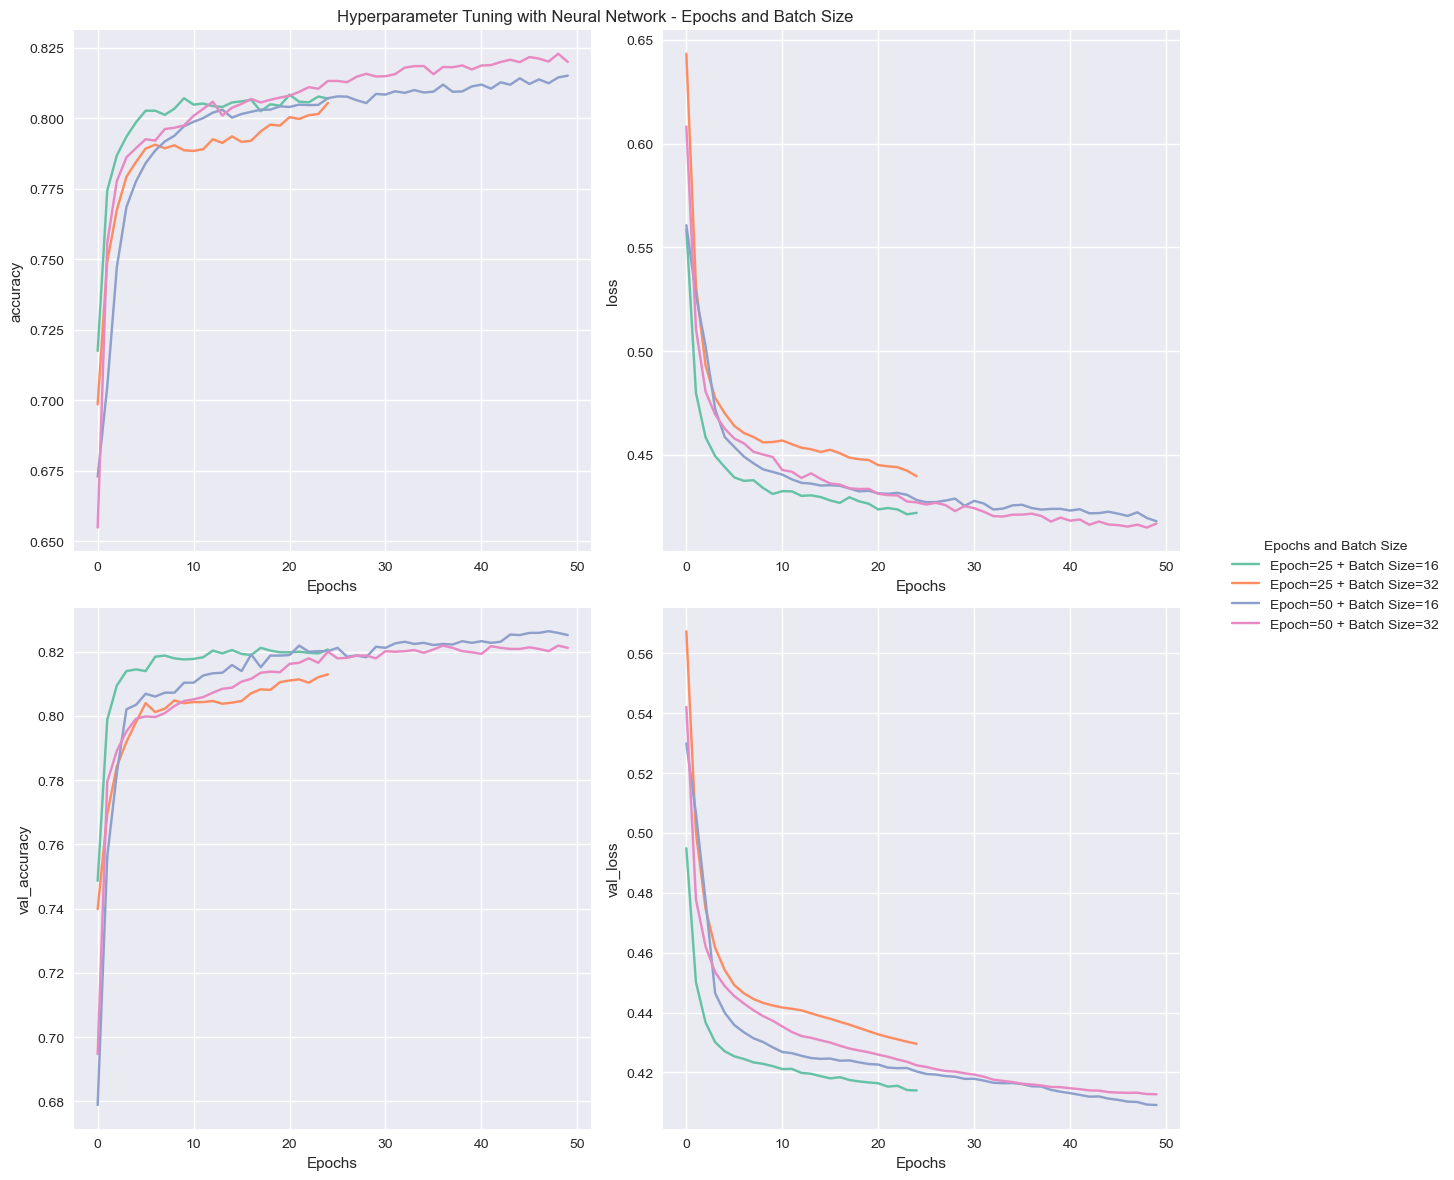

In [90]:
Display_NN_HP_Tuning(history_list, "Epochs and Batch Size", 
                     hyperparam_values = ["Epoch=25 + Batch Size=16", "Epoch=25 + Batch Size=32", 
                                          "Epoch=50 + Batch Size=16", "Epoch=50 + Batch Size=32"])

The training and validation accuracy/loss plots show that the model can still improve further with more epochs. Comparing batch sizes, `batch size = 32` has a better accuracy and loss for the training dataset, but a lower accuracy and loss for the validation dataset to `batch size = 16`. We can see that there is better generalisation with unseen data (validation dataset) with a lower batch size.

In this case, we will be using `epoch = 50` and `batch_size = 16`.

Now that we have computed the hyperparameters individually, lets create our final/selected Neural Network model. We will be using `KerasClassifier` which can use functions like `.fit()` and `.predict()`

Note: If you want to use GridSearchCV, you may take a look at the code below. This ensures that you find the best tuning by combining all hyperparameters together.

```python
nn_param_grid = {
    "model__learning_rate": [1e-05, 1e-04, 1e-03, 1e-02, 1e-01],
    "model__layer1_units": [4, 8],
    "model__layer2_units": [4, 8],
    "model__layer1_dropout_rate": [0.05, 0.1],
    "model__layer2_dropout_rate": [0.05, 0.1],
    "model__layer1_activation": ["relu", "tanh"],
    "model__layer2_activation": ["relu", "tanh"],
    "batch_size": [16, 32],
    "epochs": [25, 50]
}

set_seed() # Do not forget to set the seed!

nn = GridSearchCV(
    estimator = KerasClassifier(model = model_factory, input_dim = 10),
    param_grid = nn_param_grid,
    cv = cv_method,
    scoring = scoring_method,
    verbose = verbose_category
)

nn.fit(x_train_pp, y_train)
```

In [91]:
%%time

set_seed()
selected_nn_model = KerasClassifier(model = model_factory, 
                                    input_dim = 10, learning_rate = 0.01,
                                    layer1_units = 8, layer2_units = 8, 
                                    layer1_dropout_rate = 0.05, layer2_dropout_rate = 0.05, 
                                    layer1_activation = "tanh", layer2_activation = "relu")

selected_nn_model.fit(x_train_pp_split, y_train_split, epochs = 50, batch_size = 16,
                      verbose = verbose_category, shuffle = True,
                      validation_data = (x_val_pp_split, y_val_split))

Epoch 1/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7126 - loss: 0.5518 - val_accuracy: 0.8008 - val_loss: 0.4489
Epoch 2/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8003 - loss: 0.4428 - val_accuracy: 0.8132 - val_loss: 0.4378
Epoch 3/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8058 - loss: 0.4375 - val_accuracy: 0.8127 - val_loss: 0.4339
Epoch 4/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8064 - loss: 0.4326 - val_accuracy: 0.8117 - val_loss: 0.4308
Epoch 5/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8100 - loss: 0.4304 - val_accuracy: 0.8125 - val_loss: 0.4286
Epoch 6/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8093 - loss: 0.4270 - val_accuracy: 0.8124 - val_loss: 0.4270
Epoch 7/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8121 - loss: 0.4246 - val_accuracy: 0.8131 - val_loss: 0.4252
Epoch 8/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8129 - loss: 0.4234 - 

KerasClassifier(
	model=<function model_factory at 0x000002285682EF20>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	input_dim=10
	learning_rate=0.01
	layer1_units=8
	layer2_units=8
	layer1_dropout_rate=0.05
	layer2_dropout_rate=0.05
	layer1_activation=tanh
	layer2_activation=relu
	class_weight=None
)

In [92]:
selected_nn_hist_df = pd.DataFrame(selected_nn_model.history_)

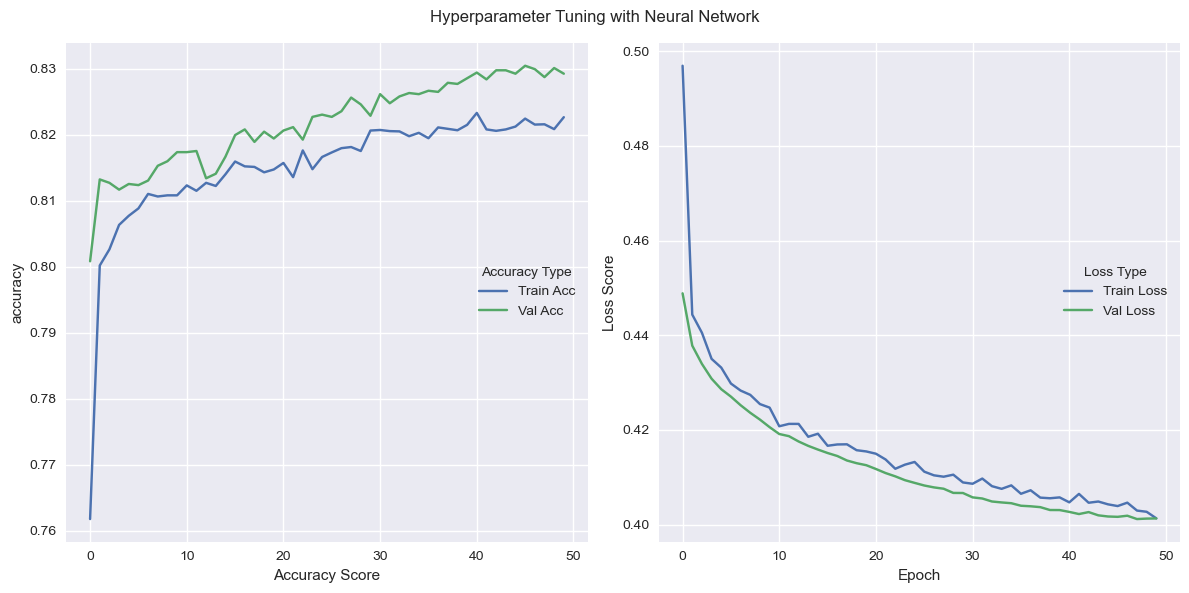

In [93]:
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize = (12, 6))

fig.suptitle("Hyperparameter Tuning with Neural Network")

sns.lineplot(data = selected_nn_hist_df, x = selected_nn_hist_df.index, y = "accuracy", label = "Train Acc", ax = ax_acc)
sns.lineplot(data = selected_nn_hist_df, x = selected_nn_hist_df.index, y = "val_accuracy", label = "Val Acc", ax = ax_acc)

sns.lineplot(data = selected_nn_hist_df, x = selected_nn_hist_df.index, y = "loss", label = "Train Loss", ax = ax_loss)
sns.lineplot(data = selected_nn_hist_df, x = selected_nn_hist_df.index, y = "val_loss", label = "Val Loss", ax = ax_loss)

ax_acc.set_xlabel("Epoch")
ax_acc.set_xlabel("Accuracy Score")
ax_acc.legend(loc = "center right", title = "Accuracy Type")

ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss Score")
ax_loss.legend(loc = "center right", title = "Loss Type")

plt.tight_layout()
plt.show()

With the new hyperparameter values, our accuracy score goes above 0.82, with the validation accuracy surpassing 0.83, and our loss score going down as low as 0.4.

### <a id = "model-comparison">4.5. Model Comparison<a/>

In the final section for predictive modelling, we compare the best performing model from each machine learning algorithm (Logistic Regression, Decision Tree, Random Forest and Neural Network).

Using the unseen/testing dataset, we re-evaluate each models using `F1-scores`, and compare the difference in model performances. We also use paired t-tests `ttest_rel` to see if the pariwise model performances being different are statistically significant. This allows us to understand if a model significantly outperforms the other, rather than the difference being due to random chance.

Lets preprocess the testing dataset first, with the same one hot encoding and power transformer available to us. We must ensure that we only transform and not fit the test dataset by setting `transform_only = True`

After that, we also select the k = 10 features that we found using `f_classif` and `SelectKBest` in our feature selection phase.

In [94]:
x_test_pp = Ohe_Features(x_test, m_ohe, multi_categorical_features, transform_only = True)
x_test_pp = PowerTransform_Features(x_test_pp, pt, numerical_features, transform_only = True)
x_test_pp = x_test_pp.loc[:, selected_columns]

In [95]:
x_test_pp.head()

,required_car_parking_space,repeated_guest,type_of_meal_plan_Meal Plan 2,market_segment_type_Corporate,market_segment_type_Online,no_of_adults,lead_time,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
4968,0,0,0,0,1,0.261496,-1.478655,-0.152316,-0.358852,1.709833
34540,0,0,0,0,0,0.261496,-1.074183,-0.152316,-1.595387,-0.897358
36108,0,0,0,0,1,0.261496,-0.555472,-0.152316,-0.209770,0.888827
1553,0,0,0,0,1,0.261496,-0.581431,-0.152316,0.697874,-0.897358
24974,0,0,0,0,1,0.261496,-1.074183,-0.152316,2.653615,1.443944


Lets create a dictionary to store our selected models for each machine learning algorithm, and run the `cross_val_score` for each model and the testing dataset.

We will also be doing the same for the training dataset to see if there are any abnormalities or differences in training and testing for all machine learning algorithms.

In [96]:
selected_models = {
    "lr": {
        "model": selected_lr_model
    }, 
    "dt": {
        "model": selected_dt_model
    }, 
    "rf": {
        "model": selected_rf_model
    },
    "nn": {
        "model": selected_nn_model
    }
}

set_seed()

for model_name, model_details in selected_models.items():
    model = selected_models[model_name]["model"]

    # Cross Validation with Training Set
    train_cv_results = cross_val_score(estimator = model,
                                       X = x_train_pp, y = y_train, 
                                       cv = cv_method, scoring = scoring_method)
    selected_models[model_name]["train_cv_results"] = train_cv_results
    
    # Cross Validation with Testing Set
    test_cv_results = cross_val_score(estimator = model,
                                      X = x_test_pp, y = y_test, 
                                      cv = cv_method, scoring = scoring_method)
    selected_models[model_name]["test_cv_results"] = test_cv_results

726/726 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6769 - loss: 0.5925
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
726/726 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6717 - loss: 0.5986
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
726/726 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7034 - loss: 0.5908
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
726/726 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6462 - loss: 0.6219
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
726/726 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6273 - loss: 0.6388
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6078 - loss: 0.6537
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5511 - loss: 0.6789
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6272 - loss: 0.6488
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5474 - loss: 0.7132
46/

Lets create a dataframe to store the results

In [97]:
model_comparison_list = []

for model_name, model_details in selected_models.items():
    for score in model_details["train_cv_results"]:
        model_comparison_list.append({"Model": model_name, "Dataset": "Train", "F1-score": score})
        
    for score in model_details["test_cv_results"]:
        model_comparison_list.append({"Model": model_name, "Dataset": "Test", "F1-score": score})


model_comparison_df = pd.DataFrame(model_comparison_list)

In [98]:
model_comparison_df.sample(n = 5, random_state = random_state)

,Model,Dataset,F1-score
19,dt,Test,0.731606
16,dt,Test,0.749232
15,dt,Test,0.716511
26,rf,Test,0.774332
4,lr,Train,0.664546


We can compare the F1-Scores for the machine learning models for both training and testing dataset.

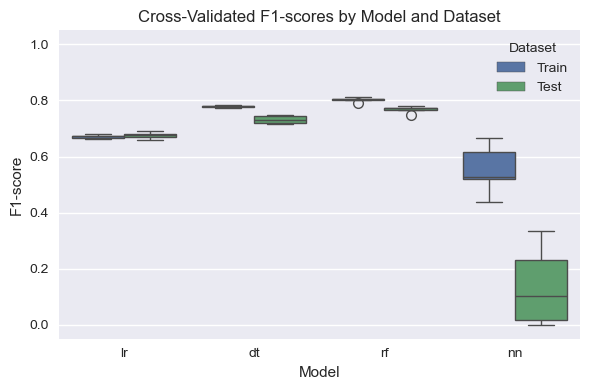

In [99]:
plt.figure(figsize = (6, 4))
sns.boxplot(data = model_comparison_df, x = "Model", y = "F1-score", hue = "Dataset")

plt.title("Cross-Validated F1-scores by Model and Dataset")
plt.ylim([-0.05, 1.05])
plt.tight_layout()
plt.show()

- `Logistic Regression`<br>
While not be the best performing model, it is also not the worst. `Logistic Regression` shows the most balanced in F1-scores for both training and testing datasets. This means that the model is able to generalise well to unseen data without overfitting, making it a reliable model.
- `Decision Tree`<br>
While performing better than `Logistic Regression`, it falls short to `Random Forest`. More importantly, the testing F1-score is lower than the training score. There is also a wider spread in the testing F1-score boxplot. This means that the model may have overfitted to the training dataset and struggles to generalise to new or unseen observations.
- `Random Forest`<br>
Out of all models, `Random Forest` performed the best. However, similar to `Decision Tree`, it also shows a drop in F1-score when comparing training and testing datasets. This shows that there may be overfitting. That said, the performance gap between training and testing is smaller than `Decision Tree`, and the testing F1-score distribution is tighter, making it a more robust and better in generalisation than `Decision Tree`
- `Neural Network`<br>
Unfortunately, `Neural Network` performed the worst. It shows lower F1-scores on both training and testing datasets. There is also a much larger range of F1-scores, as seen by the wider boxplots. This could be due to insufficient hyperparameter tuning, epochs during training, or sensitivity to a small dataset size. Further tuning and possibilty a larger dataset might improve the performance of `Neural Network` models.

Lets analyse the pairwise t-test statistical scores.

In [100]:
model_names = list(selected_models.keys())

t_test_df = pd.DataFrame(np.zeros((len(model_names), len(model_names))),
                         index = model_names, columns = model_names)

t_test_p_val_df = pd.DataFrame(np.zeros((len(model_names), len(model_names))),
                               index = model_names, columns = model_names)

t_test_t_score_df = pd.DataFrame(np.zeros((len(model_names), len(model_names))),
                                 index = model_names, columns = model_names)

for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        model1, model2 = model_names[i], model_names[j]
        
        model1_scores = list(model_comparison_df.loc[(model_comparison_df["Model"] == model_names[i]) & (model_comparison_df["Dataset"] == "Test"), "F1-score"])
        model2_scores = list(model_comparison_df.loc[(model_comparison_df["Model"] == model_names[j]) & (model_comparison_df["Dataset"] == "Test"), "F1-score"])
        
        t_score, p_val = ttest_rel(model1_scores, model2_scores)

        t_test_t_score_df.loc[model1, model2] = t_score
        t_test_t_score_df.loc[model2, model1] = t_score
        
        t_test_p_val_df.loc[model1, model2] = p_val
        t_test_p_val_df.loc[model2, model1] = p_val

        annotation = f"t score={t_score:.5f}\np value={p_val:.5f}"
        t_test_df.loc[model1, model2] = annotation
        t_test_df.loc[model2, model1] = annotation

In [101]:
t_test_df

,lr,dt,rf,nn
lr,0.0,t score=-8.33354\np value=0.00113,t score=-10.96177\np value=0.00039,t score=8.13013\np value=0.00125
dt,t score=-8.33354\np value=0.00113,0.0,t score=-8.23110\np value=0.00119,t score=8.95556\np value=0.00086
rf,t score=-10.96177\np value=0.00039,t score=-8.23110\np value=0.00119,0.0,t score=10.04745\np value=0.00055
nn,t score=8.13013\np value=0.00125,t score=8.95556\np value=0.00086,t score=10.04745\np value=0.00055,0.0


In [102]:
t_test_t_score_df

,lr,dt,rf,nn
lr,0.000000,-8.333542,-10.961775,8.130127
dt,-8.333542,0.000000,-8.231095,8.955561
rf,-10.961775,-8.231095,0.000000,10.047453
nn,8.130127,8.955561,10.047453,0.000000


In [103]:
t_test_p_val_df

,lr,dt,rf,nn
lr,0.000000,0.001133,0.000393,0.001245
dt,0.001133,0.000000,0.001188,0.000860
rf,0.000393,0.001188,0.000000,0.000552
nn,0.001245,0.000860,0.000552,0.000000


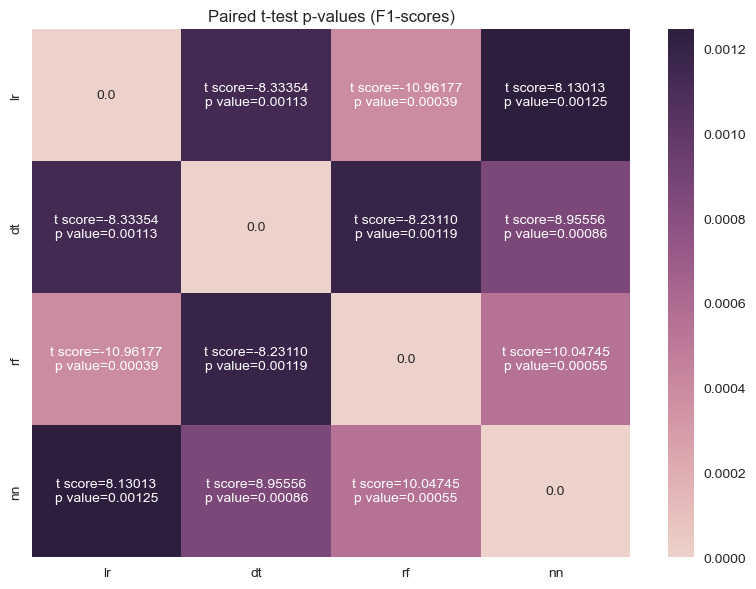

In [104]:
plt.figure(figsize = (8, 6))

sns.heatmap(t_test_p_val_df, annot = t_test_df, fmt = "", cmap = sns.cubehelix_palette(as_cmap = True))

plt.title("Paired t-test p-values (F1-scores)")

plt.tight_layout()
plt.show()

The above heatmap shows the paired t-test results by comparing F1-score distributions between each pair of models. The goal is to identify if the differences in model performances with F1-scores are statistically significant.

Each cell shows both the `t-scores` and `p-values`. `t-scores` show the direction/magnitude difference between the models, and `p-values` indicate the statistical significance.

Firstly, all p-values are less than 0.05. This means that the pairwise comparisons show statistically significant differences in F1-scores, and are not due to randomness.

For the pairwise comparisions, we can look at `t-scores` and see that the order of performances are as follows from weakest to strongest:

`Neural Network` -> `Logistic Regression` -> `Decision Tree` -> `Random Forest`

---

## <a id = "critique-limitations">5. Critique & Limitations<a/>

This project demonstrated a comprehensive approach to building machine learning models to solve a binary classification problem (Predicting Hotel Booking Cancellations). While the process was thorough and methodologically sound, several challenges and limitations were encounted.

1) Computational Time<br>
One of the main limitations was the long execution time required to train and fine tune the hyperparameters of all models, especially the Neural Network model.
<br><br>
Using the `%%time` to keep track of how long each cell took to run, we can see that the entire python notebook took more than an hour to run from start to finish, even though we choose a handful of hyperparameters to tune, the few values selected for each hyperparameter, not using cross validation and GridSearch for Neural Networks.
<br><br>
Training a Neural Network with cross validation would have significantly increased the time, and given that the code was executed using a CPU, this is not optimal for Deep Learning.

2) Neural Network<br>
While more time was spent on developing Neural Network models, the final results show that it has underperformed compared to the rest of the models, which required a less complicated process in building them.
<br><br>
However, the outcomes show the importance of model selection. Mode complex models do not always outperform simple models.

That said, our project came with good findings:

1) Modelling Pipeline<br>
While processing and computational time is a key issue in our project, this project followed a clear and structured methodology for machine learning workflow in developing models. Preprocessing, Feature Selection, Model Training and Hyperparameter Tuning, and Evaluation of the models.

2) Comparing multiple models<br>
We were able to use a combination of traditional and modern machine learning algorithms, providing good insights into each of their strengths and weakness

3) Statistical Testing<br>
Using paried t-tests with `ttest_rel`, we are able to identify that the difference in model performances were significant.

---

## <a id = "summary-conclusions">6. Summary & Conclusions<a/>

### <a id = "project-summary">6.1. Project Summary<a/>

In this project, we aimed to predict hotel booking cancellations using maching learning techniques across two phases.

In Phase 1, we explored the hotel booking cancellation dataset by performing data cleaning and preparation, and exploratory data analysis.

We started by examining the dataset structure to gain an understand of features and their meanings, and categorise them as independent and dependent features to guide the modelling process in Phase 2.

Next, we conducted data cleaning and preparation to address issues and improve data integrity and quality. This included resolving inconsistencies in cardinality, handling missing values and correcting data types. After which, we analysed patterns and relationships between key features with exploratory data analysis, using statistical summaries and graphical visualisation. We use boxplots, histograms and pie charts to uncover potential features or trends that can lead to hotel booking cancellations.

In Phase 2, we trained and evaluated machine learning models, specifically Logistic Regression, Decision Trees, Random Forests and Neural Networks that can be used for binary classification problems.

Before building models, we had to preprocess the dataset, by conducting encoding for categorical features and scaling/transforming for numerical features. To reduce the number of features, we also conducted feature selection, and selected the top 10 features with the best predictive power to the target feature. After that, we split our dataset into training and testing datasets. The training dataset would be used to train the models, while testing dataset would be used to test the model's performance on unseen data. We also used StratifiedKFold for cross validation and used F1-score as our scoring metric for all models.

For model building, we tuned hyperparameters and visualised the results with graphical representations. We use GridSearchCV for Logistic Regression, Decision Trees and Random Forests, while we compared each hyperparameter individually for Neural Networks, in hopes to get optimal hyperparameter values, while taking lesser computational time to train.

Finally, we compared the best model performances for each machine learning model algorithm, and run the testing datasets to evaluate the F1-scores for unseen datasets. We also performed paired t-tests to identify if the difference F1-scores between models were statistically significant.

### <a id = "summary-of-findings">6.2. Summary of Findings<a/>

Feature Selection showed that the leading time, number of special requests and average price per room were key factors in influencing hotel booking cancellations.

With our models, Random Forest performed the best, with an F1-score close to 0.8 for unseen data. Paired t-tests also showed that the difference in model performances is significant, at a 95% confidence level.

Training a Neural Network model is not feasible with a dataset having little observations, and better equipments such as using a GPU would speed up the tuning and training process.

### <a id = "conclusions">6.3. Conclusions<a/>

In conclusion, we have successfully build a machine learning model suitable for predicting hotel cancellations. It took 2 phases to complete the main data science cycle workflow, starting off with understanding the dataset. This is followed by a comprehensive data cleaning and preparation, analysing the dataset features with exploratory data analysis, and finally, the training and building of machine learning models with scoring evaluations to select the best model.

Throughout each stage, we addressed critical issues such as dealing with issues in datasets, ensuring that our data integrity and quality is of top quality before analysis and modelling. Exploratory data analysis provided insights into booking behaviours and patterns, with leading time being the most influential feature affecting booking cancellations.

We implemented various machine learning algorithms like Logistic Regression, Decision Trees, Random Forests and Neural Networks. Out of all these, Random Forest emrged as the best overall performance across F1-score, which balances out precision and recall scores, making it the most suitable model for prediction.

We show that this project is able to provide practical value in the hospitality industry, helping hotels anticipate booking cancellations and ultimately, take proactive measures to optimise guest bookings and reduce revenue loss and manage manpower better.

### <a id = "next-steps">6.4. Next Steps<a/>

Some options for further improvement are as follows:

1) Build a time-series model as an alternative to analyse and predict booking cancellations by arrival dates
2) Conduct cross validation when testing skewness in numerical features, to get a fairer and more accurate test result
3) Use Cross Validation and Grid Search when tuning Neural Network models

---

## <a id = "references">7. References<a/>

1)	Raza A. (n.d.). Hotel Reservations Dataset. Kaggle. https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset

---